# Avocado Price Prediction and Type Classification using Ml Models

In [87]:
import pandas as pd
import numpy as np
from plotnine import *

In [88]:
avocado_raw = pd.read_csv('avocado.csv')

## 1.  Data Preparation
+ Convert Date column to datetime format
+ Handle missing values
+ Extract features such as month and year
+ Aggregate data if necessary

In [89]:
avocado_raw.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [90]:
avocado_raw.shape

(18249, 14)

### Data Cleaning

In [91]:
import janitor
avocado = avocado_raw.clean_names().drop('unnamed_0', axis=1)
avocado.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [92]:
#converting from wide to long format
avocado_long = (avocado.pivot_longer(index = ['date','averageprice','total_volume','total_bags', 'small_bags', 'large_bags', 'xlarge_bags','type','year','region'],
                names_to = 'plu_code',
                values_to = 'plu_volume',
                dropna = True
                                    )
.pivot_longer(index = ['date','averageprice','total_volume','total_bags','type','year','region','plu_code', 'plu_volume'],
                                          names_to = 'bag_type',
                                          values_to = 'bag_volume',
                                          dropna = True))
avocado_long = avocado_long.rename(columns={'averageprice': 'average_price'})

avocado_long['bag_type'] = avocado_long['bag_type'].str.replace('_', ' ')
avocado_long.head()

,date,average_price,total_volume,total_bags,type,year,region,plu_code,plu_volume,bag_type,bag_volume
0,12/27/2015,1.33,64236.62,8696.87,conventional,2015,Albany,4046,1036.74,small bags,8603.62
1,12/20/2015,1.35,54876.98,9505.56,conventional,2015,Albany,4046,674.28,small bags,9408.07
2,12/13/2015,0.93,118220.22,8145.35,conventional,2015,Albany,4046,794.70,small bags,8042.21
3,12/6/2015,1.08,78992.15,5811.16,conventional,2015,Albany,4046,1132.00,small bags,5677.40
4,11/29/2015,1.28,51039.60,6183.95,conventional,2015,Albany,4046,941.48,small bags,5986.26


In [93]:
#Checking for missing values
avocado_long.isna().sum()
#there are no missing values

date             0
average_price    0
total_volume     0
total_bags       0
type             0
year             0
region           0
plu_code         0
plu_volume       0
bag_type         0
bag_volume       0
dtype: int64

In [94]:
avocado_long.duplicated().sum()
#there are no duplicates

np.int64(0)

In [95]:
#SUMMARY STATISTICS
avocado_long.describe()

,average_price,total_volume,total_bags,year,plu_volume,bag_volume
count,164241.000000,1.642410e+05,1.642410e+05,164241.000000,1.642410e+05,1.642410e+05
mean,1.405978,8.506440e+05,2.396392e+05,2016.147899,2.036676e+05,7.987973e+04
std,0.402667,3.453461e+06,9.862184e+05,0.939916,1.018259e+06,4.595649e+05
min,0.440000,8.456000e+01,0.000000e+00,2015.000000,0.000000e+00,0.000000e+00
25%,1.100000,1.083858e+04,5.088640e+03,2015.000000,2.350000e+02,0.000000e+00
50%,1.370000,1.073768e+05,3.974383e+04,2016.000000,5.005720e+03,1.698160e+03
75%,1.660000,4.329623e+05,1.107834e+05,2017.000000,6.731604e+04,2.724524e+04
max,3.250000,6.250565e+07,1.937313e+07,2018.000000,2.274362e+07,1.338459e+07


In [96]:
avocado_long.skew(numeric_only = True)

average_price     0.580260
total_volume      9.007029
total_bags        9.755359
year              0.215323
plu_volume       10.716275
bag_volume       14.672502
dtype: float64

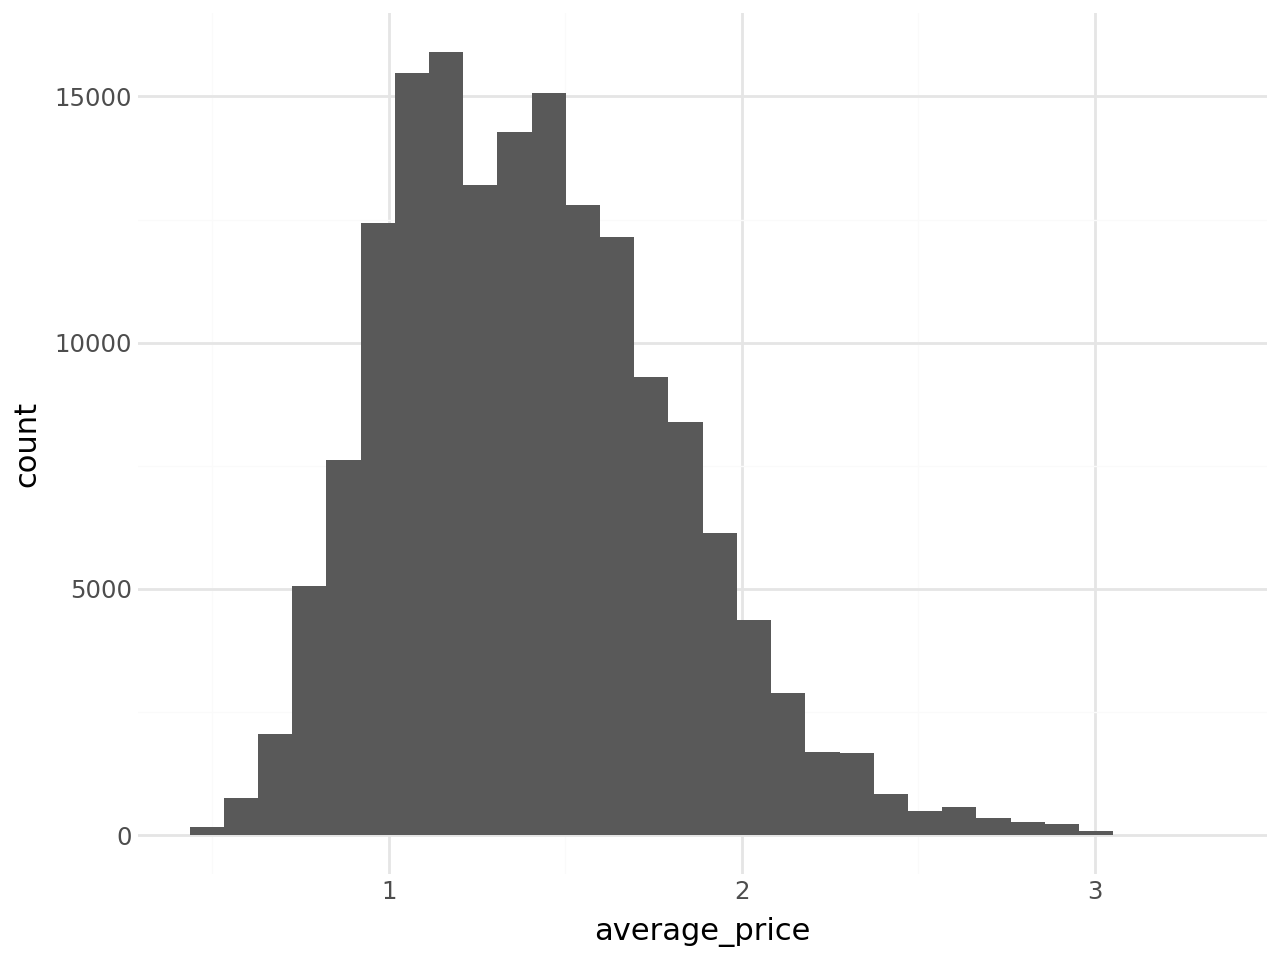

In [97]:
(ggplot(avocado_long, aes('average_price'))
+ geom_histogram(bins=30)
+ theme_minimal()
 )

In [98]:
avocado_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164241 entries, 0 to 164240
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           164241 non-null  object 
 1   average_price  164241 non-null  float64
 2   total_volume   164241 non-null  float64
 3   total_bags     164241 non-null  float64
 4   type           164241 non-null  object 
 5   year           164241 non-null  int64  
 6   region         164241 non-null  object 
 7   plu_code       164241 non-null  object 
 8   plu_volume     164241 non-null  float64
 9   bag_type       164241 non-null  object 
 10  bag_volume     164241 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 13.8+ MB


In [99]:
#converting date column to date time format
avocado_long['date'] = pd.to_datetime(avocado_long['date'])
avocado_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164241 entries, 0 to 164240
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           164241 non-null  datetime64[ns]
 1   average_price  164241 non-null  float64       
 2   total_volume   164241 non-null  float64       
 3   total_bags     164241 non-null  float64       
 4   type           164241 non-null  object        
 5   year           164241 non-null  int64         
 6   region         164241 non-null  object        
 7   plu_code       164241 non-null  object        
 8   plu_volume     164241 non-null  float64       
 9   bag_type       164241 non-null  object        
 10  bag_volume     164241 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 13.8+ MB


In [100]:
# Extract features such as month and year
## Create a Year column (Year is already present in the data set)
avocado_long['year'] = avocado_long['date'].dt.year

## Create a Month column
avocado_long['month'] = avocado_long['date'].dt.month
avocado_long['day'] = avocado_long['date'].dt.day
avocado = avocado_long
avocado.head()

,date,average_price,total_volume,total_bags,type,year,region,plu_code,plu_volume,bag_type,bag_volume,month,day
0,2015-12-27,1.33,64236.62,8696.87,conventional,2015,Albany,4046,1036.74,small bags,8603.62,12,27
1,2015-12-20,1.35,54876.98,9505.56,conventional,2015,Albany,4046,674.28,small bags,9408.07,12,20
2,2015-12-13,0.93,118220.22,8145.35,conventional,2015,Albany,4046,794.70,small bags,8042.21,12,13
3,2015-12-06,1.08,78992.15,5811.16,conventional,2015,Albany,4046,1132.00,small bags,5677.40,12,6
4,2015-11-29,1.28,51039.60,6183.95,conventional,2015,Albany,4046,941.48,small bags,5986.26,11,29


### Feature Engineering

In [101]:
#Creating a season column
avocado['month'] = avocado['month'].astype(int)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

avocado['season'] = avocado['month'].apply(get_season)

In [102]:
# how many rows fall in each season
avocado['season'].value_counts()

season
Winter    45675
Spring    42768
Fall      37908
Summer    37890
Name: count, dtype: int64

In [103]:
#average price per season
avocado.groupby('season')['average_price'].mean().sort_values(ascending=False)

season
Fall      1.536147
Summer    1.462572
Spring    1.349266
Winter    1.304100
Name: average_price, dtype: float64

In [104]:
# unique type
print(avocado['type'].unique())

['conventional' 'organic']


In [105]:
avocado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164241 entries, 0 to 164240
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           164241 non-null  datetime64[ns]
 1   average_price  164241 non-null  float64       
 2   total_volume   164241 non-null  float64       
 3   total_bags     164241 non-null  float64       
 4   type           164241 non-null  object        
 5   year           164241 non-null  int32         
 6   region         164241 non-null  object        
 7   plu_code       164241 non-null  object        
 8   plu_volume     164241 non-null  float64       
 9   bag_type       164241 non-null  object        
 10  bag_volume     164241 non-null  float64       
 11  month          164241 non-null  int64         
 12  day            164241 non-null  int32         
 13  season         164241 non-null  object        
dtypes: datetime64[ns](1), float64(5), int32(2), int64(1)

In [106]:
season_distribution = avocado['season'].value_counts().reset_index()
season_distribution

,season,count
0,Winter,45675
1,Spring,42768
2,Fall,37908
3,Summer,37890


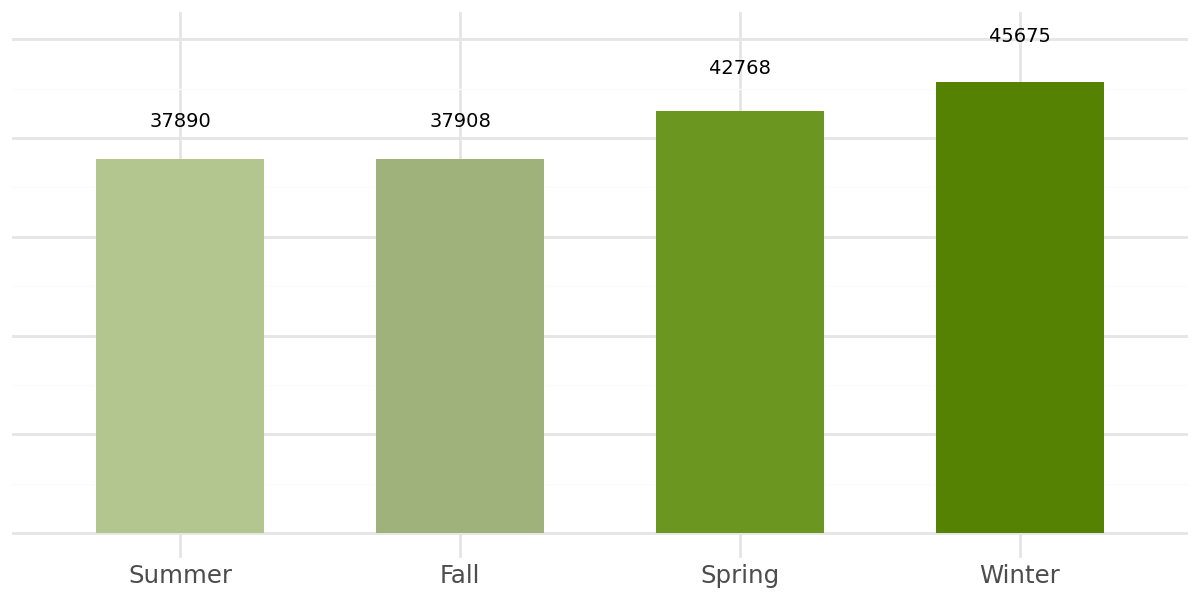

In [107]:
#season_distribution['fill'] = season_distribution['count']==season_distribution['count'].max()
(ggplot(season_distribution, aes('reorder(season, count)', 'count', fill='season'))
 + geom_col(show_legend=False, width=0.6)
 +  geom_text(aes(label = 'count'), position = position_stack(vjust = 1.1), size = 7)
 + labs(x='Seasons', y='Count')
 + theme_minimal()
 + theme(#axis_line_x = element_blank(),
        axis_text_y = element_blank(),
        #axis_ticks_x = element_blank(),
        axis_title_x = element_blank(),
        axis_line_y = element_blank(),
        axis_title_y = element_blank(),
        figure_size=(6,3))
# + scale_fill_manual(values={True:'#62866c', False: '#c9c9c9'})
 + scale_fill_manual(values={'Winter':'#568203', 
                             'Spring':'#6b9721', 
                             'Fall':'#a0b27c',
                             'Summer':'#b4c68f'})
)

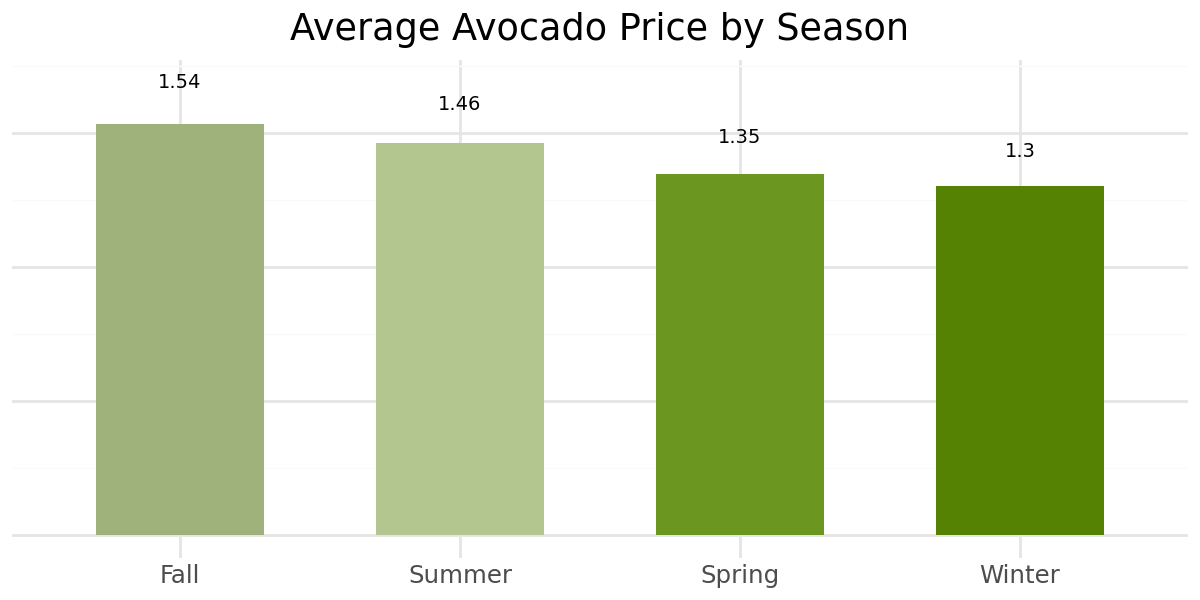

In [108]:
season_avg = avocado.groupby('season')['average_price'].mean().reset_index().sort_values(by='average_price',ascending=False)
season_avg['season'] = pd.Categorical(season_avg['season'], categories=season_avg['season'], ordered=True)

(ggplot(season_avg, aes('season', 'average_price', fill='season'))
+  geom_text(aes(label = 'average_price.round(2)'), position = position_stack(vjust = 1.1), size = 7)
+ geom_col(show_legend=False, width=0.6)
+ theme_minimal()
+ theme(#axis_line_x = element_blank(),
        axis_text_y = element_blank(),
        #axis_ticks_x = element_blank(),
        axis_title_x = element_blank(),
        axis_line_y = element_blank(),
        axis_title_y = element_blank(),
        figure_size=(6,3))
+ labs(title='Average Avocado Price by Season')
 + scale_fill_manual(values={'Winter':'#568203', 
                             'Spring':'#6b9721', 
                             'Fall':'#a0b27c',
                             'Summer':'#b4c68f'}))

# Interpretation
Fall has the highest median price and the widest spread, meaning prices are both high and variable in Fall. Winter has the lowest median price. All seasons show significant overlap in price ranges, which means season is a useful but not definitive predictor on its own.

# Part 1: Price Prediction
Objective: Predict avocado prices using either Linear Regression or Time series analysis

## Option A: Linear Regression

### Correlation Check

In [109]:
#correlation 
#this should be below 0.5
avocado_corr = (avocado.corr(numeric_only = True))
avocado_corr

,average_price,total_volume,total_bags,year,plu_volume,bag_volume,month,day
average_price,1.000000,-0.192752,-0.177088,0.093197,-0.160737,-0.126676,0.162409,0.027386
total_volume,-0.192752,1.000000,0.963047,0.017193,0.819597,0.688894,-0.024689,-0.009747
total_bags,-0.177088,0.963047,1.000000,0.071552,0.765891,0.715328,-0.022724,-0.004988
year,0.093197,0.017193,0.071552,1.000000,-0.003664,0.051183,-0.177050,0.004475
plu_volume,-0.160737,0.819597,0.765891,-0.003664,1.000000,0.547863,-0.020575,-0.009409
bag_volume,-0.126676,0.688894,0.715328,0.051183,0.547863,1.000000,-0.016255,-0.003568
month,0.162409,-0.024689,-0.022724,-0.177050,-0.020575,-0.016255,1.000000,0.010621
day,0.027386,-0.009747,-0.004988,0.004475,-0.009409,-0.003568,0.010621,1.000000


#### Or
Correlation using the heatmap method

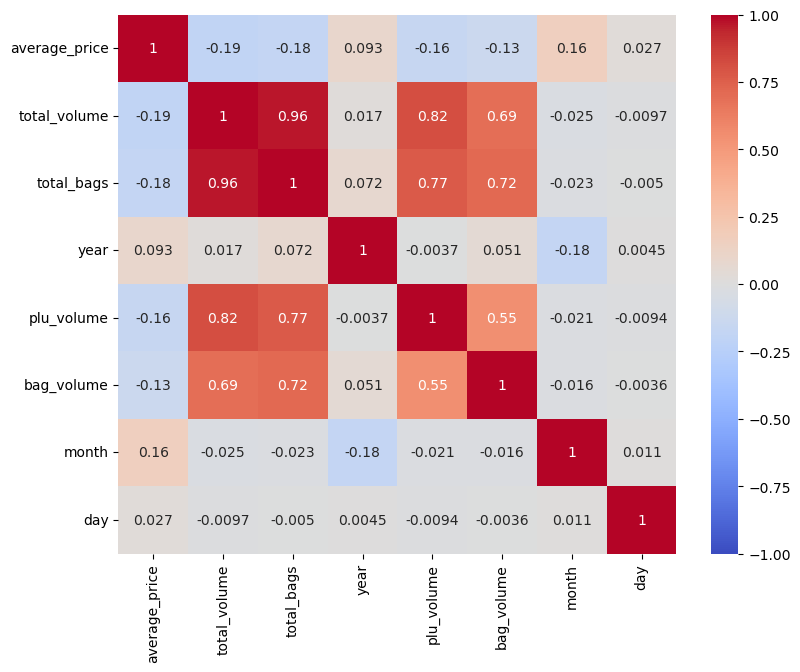

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9,7))
sns.heatmap(avocado.corr(numeric_only = True), vmin=-1, vmax=1, annot=True,  cmap='coolwarm')
plt.show()

### Interpretation
Total volume, plu volume, total bags and bag volume are strongly correlated with each other when more avocados are sold, more bags are used. Average price has a weak negative correlation with volume, confirming that higher supply slightly lowers price but the relationship is not strong enough to predict price reliably on its own.

In [111]:
from plotnine import *

### Checking for Linearity

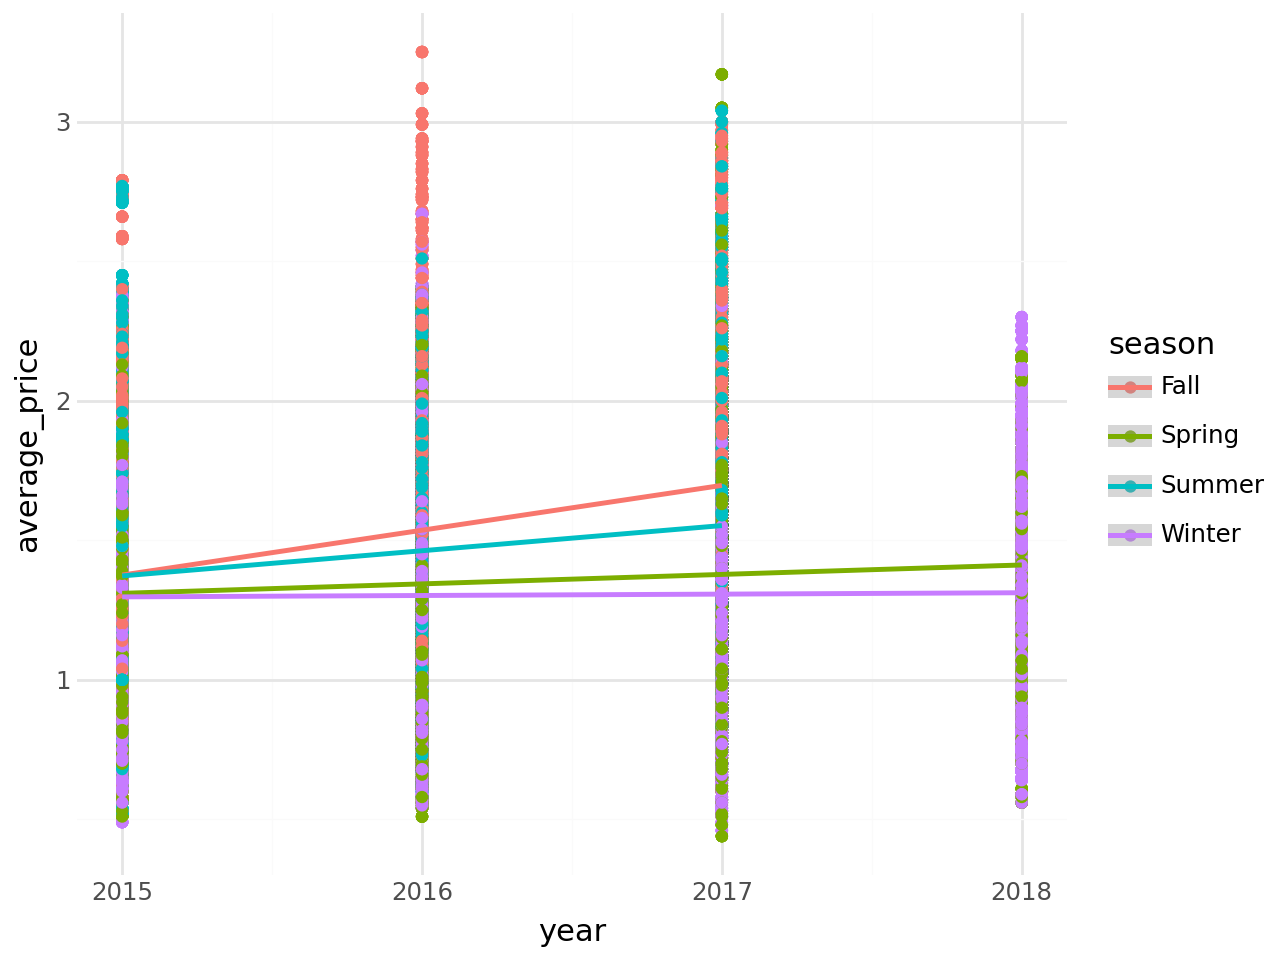

In [112]:
(ggplot(avocado, aes('year', 'average_price', color="season"))
+ geom_point()
+ geom_smooth()
+ theme_minimal()
)

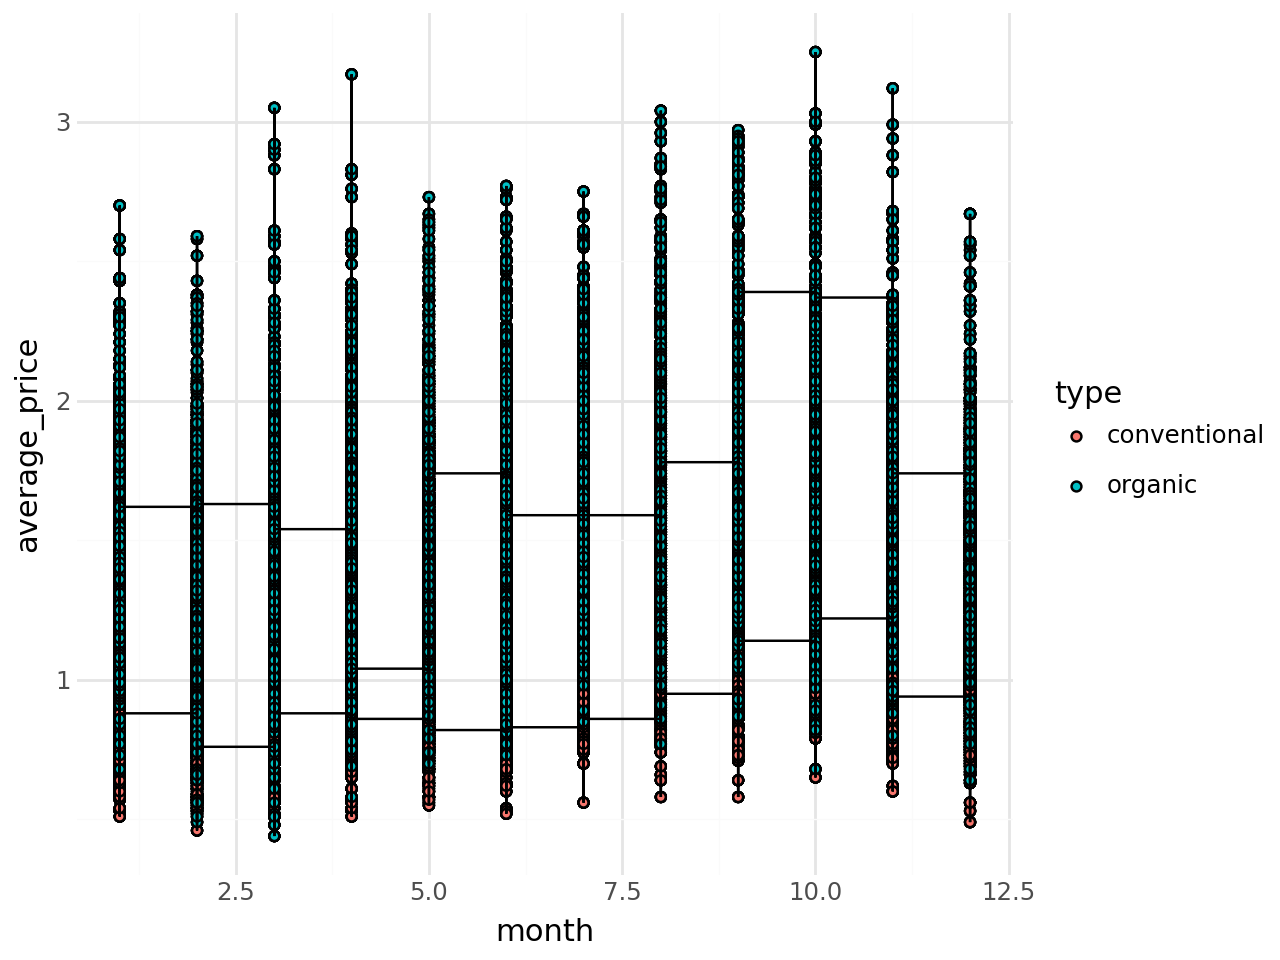

In [113]:
(ggplot(avocado, aes('month', 'average_price', fill='type'))
+ geom_point()
+ geom_step()
+ theme_minimal())

### Interpretation
Prices show a general upward trend over the years, with 2017 being the most expensive year. However the spread within each year is wide, suggesting year captures a trend but not the full picture.

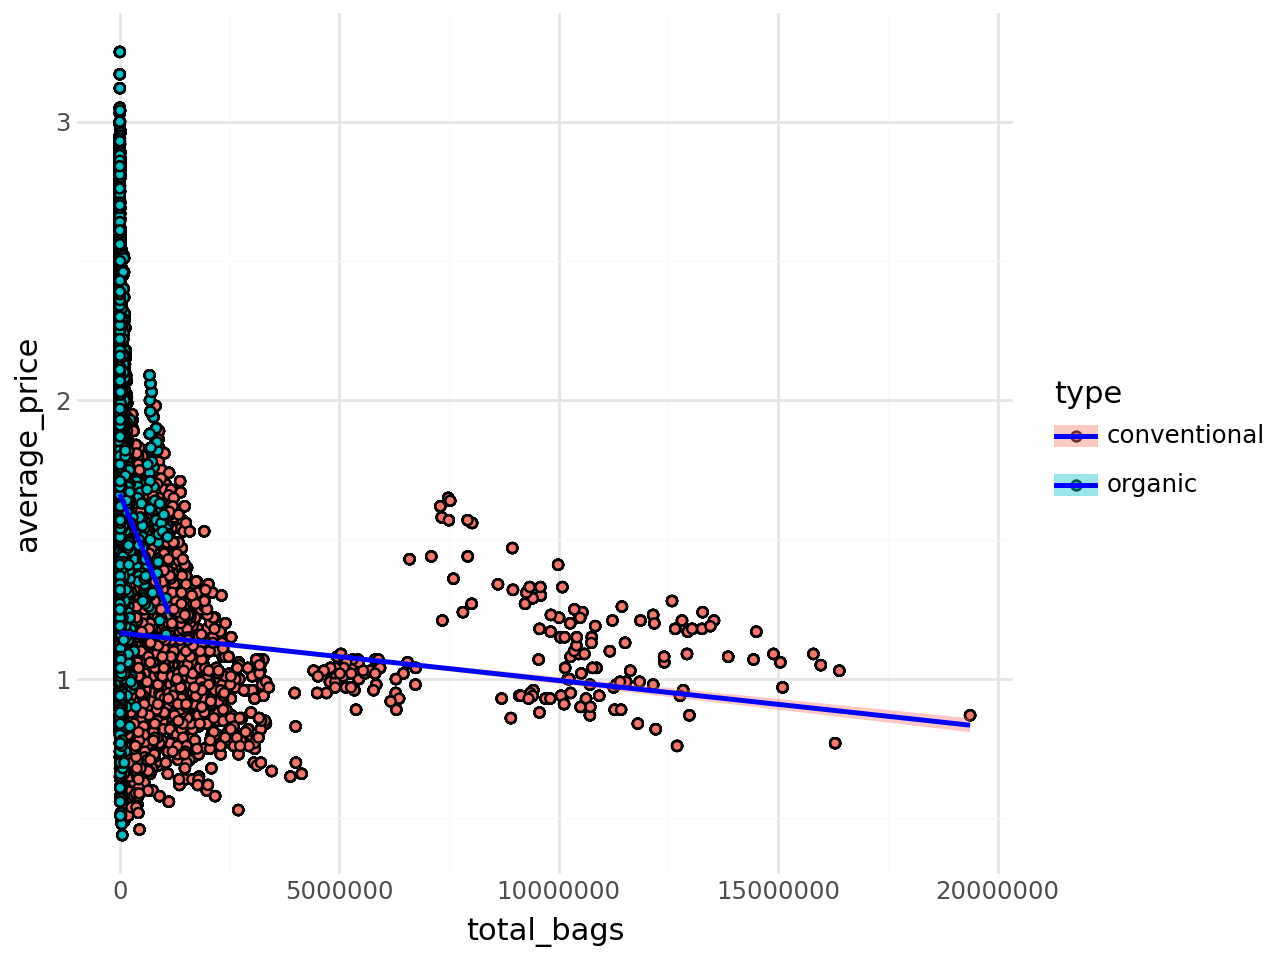

In [223]:
(ggplot(avocado, aes('total_bags', 'average_price', fill="type"))
+ geom_point()
+ geom_smooth(color="blue")
+ theme_minimal()
)

### Interpretation
There is no clear linear relationship between total bags and price. The data is heavily concentrated at lower bag volumes with a wide spread of prices, confirming that bag volume alone cannot reliably predict price.

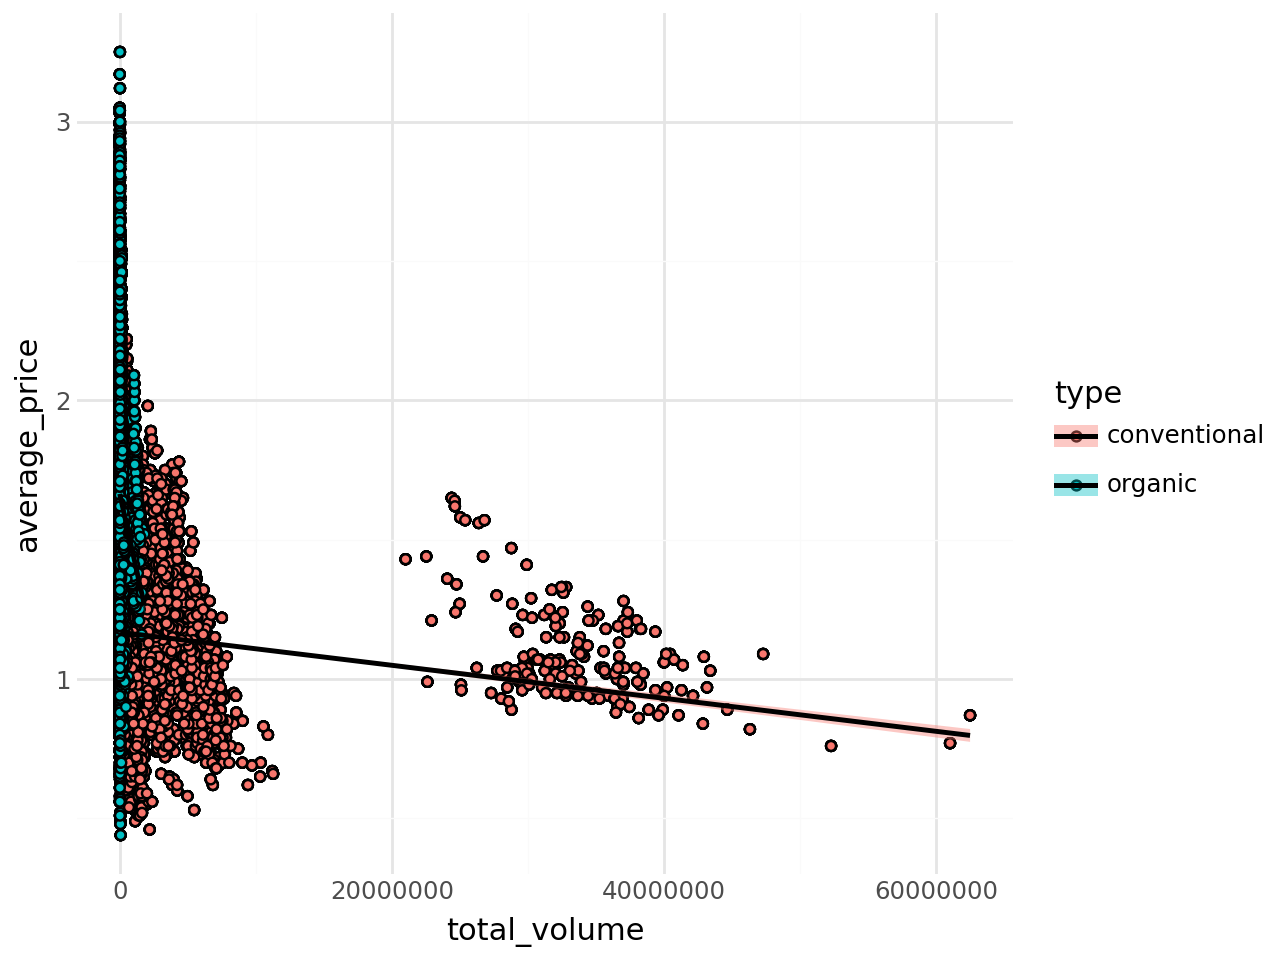

In [224]:
(ggplot(avocado, aes('total_volume', 'average_price', fill="type"))
+ geom_point()
+ geom_smooth()
+ theme_minimal()
)

### Interpretation
As total volume increases, prices tend to cluster lower more supply pulls prices down slightly. However the relationship is weak and scattered at higher volumes, confirming that volume alone is a poor predictor of price.

### Data Preprocessing

In [225]:
from sklearn.model_selection import train_test_split

## Model 1 - Linear Regression
Feature: total_volume

In [226]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [227]:
# Feature Selection
independent_variables = avocado[["type", "total_volume", "season", "region"]]
dependent_variables = avocado["average_price"]

x_train, x_test, y_train, y_test = train_test_split(independent_variables, dependent_variables, test_size=0.2, random_state=42)

print('Training set size:', x_train.shape)
print('Test set size:', x_test.shape)

Training set size: (131392, 4)
Test set size: (32849, 4)


In [228]:
#Scaling total_volume on both training andd test data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train['total_volume'] = scaler.fit_transform(x_train[['total_volume']])
x_test['total_volume'] = scaler.transform(x_test[['total_volume']])
x_train.head()

,type,total_volume,season,region
121140,organic,-0.245480,Summer,StLouis
90178,organic,-0.223670,Winter,Southeast
83085,organic,-0.243374,Summer,Houston
149581,conventional,0.562604,Winter,GreatLakes
46882,organic,-0.246426,Fall,MiamiFtLauderdale


In [229]:
from sklearn.linear_model import LinearRegression

In [230]:
# Subset a feature for Simple Linear Regression
volume_feature = x_train[['total_volume']]
volume_feature.head()

,total_volume
121140,-0.245480
90178,-0.223670
83085,-0.243374
149581,0.562604
46882,-0.246426


In [231]:
# Initiate and fit the model
volume_model = LinearRegression()
volume_model.fit(volume_feature, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Model Parameters

In [232]:
print('Intercept:',volume_model.intercept_.round(2))
print()
pd.DataFrame(volume_model.coef_, volume_feature.columns,['coefficient'])

Intercept: 1.41



,coefficient
total_volume,-0.077483


### average_price = 1.41 + (-0.077) * total_volume

### Interpretation

The base price for avocado is 1.41. For every unit increase in total volume, avocado price decrease by 0.077

### Model Evaluation

In [233]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [234]:
price_pred = volume_model.predict(volume_feature)

r_square = r2_score(y_train, price_pred)
mse = mean_squared_error(y_train, price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.037071
1,rmse,0.394899


### Interpretation
The predictive model performs with a low degree of accuracy, explaining the average price of avocado by 3.7% (r2 = 0.037). The RMSE of approximately 0.39 means predictions are off by about 39 cents on average, which is very poor. This model is not useful for prediction.

### Model 2 - Linear Regression

Feature: Total_volume and Season

In [235]:
sv_features = x_train[['total_volume','season']]
sv_encoded = pd.get_dummies(sv_features, columns=['season'], drop_first=True, dtype=int)

sv_encoded.head()

,total_volume,season_Spring,season_Summer,season_Winter
121140,-0.245480,0,1,0
90178,-0.223670,0,0,1
83085,-0.243374,0,1,0
149581,0.562604,0,0,1
46882,-0.246426,0,0,0


In [236]:
from sklearn.linear_model import LinearRegression

In [237]:
sv_model = LinearRegression()
sv_model.fit(sv_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [238]:
# Model Parameters
print('intercept:', sv_model.intercept_.round())
print()
pd.DataFrame(sv_model.coef_, sv_encoded.columns, ['coefficients'])

intercept: 2.0



,coefficients
total_volume,-0.075634
season_Spring,-0.183173
season_Summer,-0.071545
season_Winter,-0.226457


### Model Formula
#### Average Price = 2.0 + (-0.08 * Volume) + (-0.18 * Spring) + (-0.07 * Summer) + (-0.23 * Winter)

#### Interpretation
+ The Intercept is 2.0. This is the predicted average price of an avocado in Fall (when total volume is zero).

+ The Seasons (Comparison to Fall)
Fall is the most expensive season.

Spring: -0.18. In Spring, avocados are about 0.18 cheaper than in Fall (2.00 - 0.18 = 1.82).

Summer: -0.07. In Summer, they are about 0.07 cheaper than in Fall (1.93).

Winter: -0.23. In Winter, they are about 0.23 cheaper than in Fall (1.77).

#### Season is a stronger driver of price than volume alone. While volume has minimal effect, seasonal timing captures supply patterns that meaningfully affect price.

### Model Evaluation

In [239]:
sv_price_pred = sv_model.predict(sv_encoded)

r_square = r2_score(y_train, sv_price_pred)
mse = mean_squared_error(y_train, sv_price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, sv_price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.086547
1,rmse,0.384621


#### With an R-squared  of 9%, adding season improved the model slightly from 4% but it still explains very little of the price variation. Season and volume together are insufficient predictors.

### Model 3 - Linear Regression

Feature: Total_volume, Season and Type

In [240]:
#one hot encoding
svt_features = x_train[['total_volume', 'season', 'type']]
svt_features.head()

,total_volume,season,type
121140,-0.245480,Summer,organic
90178,-0.223670,Winter,organic
83085,-0.243374,Summer,organic
149581,0.562604,Winter,conventional
46882,-0.246426,Fall,organic


In [241]:
svt_encoded = pd.get_dummies(svt_features, columns = ['season','type'], drop_first=True, dtype=int)
svt_encoded.head()

,total_volume,season_Spring,season_Summer,season_Winter,type_organic
121140,-0.245480,0,1,0,1
90178,-0.223670,0,0,1,1
83085,-0.243374,0,1,0,1
149581,0.562604,0,0,1,0
46882,-0.246426,0,0,0,1


In [242]:
svt_model = LinearRegression()
svt_model.fit(svt_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [243]:
print('intercept:', svt_model.intercept_.round(2))
print()
pd.DataFrame(svt_model.coef_, svt_encoded.columns, ['coefficients'])

intercept: 1.29



,coefficients
total_volume,-0.018925
season_Spring,-0.185242
season_Summer,-0.073117
season_Winter,-0.230267
type_organic,0.487075


#### By adding Type (Organic vs. Conventional) alongside Volume and Season, the avocado price prediction have significantly improved. 
R squared value of 43% confirms that avocado type (organic vs conventional) is by far the strongest predictor. This makes commercial sense; organic avocados carry a consistent price premium regardless of season or volume, reflecting higher production costs and consumer willingness to pay more for organic produce.

In [244]:
svt_price_pred = svt_model.predict(svt_encoded)

r_square = r2_score(y_train, svt_price_pred)
mse = mean_squared_error(y_train, svt_price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, svt_price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.432926
1,rmse,0.303046


# Interpretation
Adding avocado type caused the single biggest jump in model performance R² went from 8.7% to 47%. This confirms that whether an avocado is organic or conventional is the most powerful predictor of price. Organic avocados are priced about $0.47 higher than conventional across all seasons and regions.

### Model 4 - Linear Regression

Feature: Total_volume, Season, Type and region

In [245]:
# Encoding categorical data
svtr_features = x_train[['total_volume', 'season', 'type', 'region']]
svtr_features.head()

,total_volume,season,type,region
121140,-0.245480,Summer,organic,StLouis
90178,-0.223670,Winter,organic,Southeast
83085,-0.243374,Summer,organic,Houston
149581,0.562604,Winter,conventional,GreatLakes
46882,-0.246426,Fall,organic,MiamiFtLauderdale


In [246]:
svtr_encoded = pd.get_dummies(svtr_features, columns = ['season','type','region'], drop_first=True, dtype=int)
svtr_encoded.head()

,total_volume,season_Spring,season_Summer,season_Winter,type_organic,region_Atlanta,region_BaltimoreWashington,region_Boise,region_Boston,region_BuffaloRochester,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
121140,-0.245480,0,1,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
90178,-0.223670,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
83085,-0.243374,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
149581,0.562604,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
46882,-0.246426,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [247]:
svtr_model = LinearRegression()
svtr_model.fit(svtr_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [248]:
print('intercept:', svtr_model.intercept_.round(2))
print()
pd.DataFrame(svtr_model.coef_, svtr_encoded.columns, ['coefficients'])

intercept: 1.45



,coefficients
total_volume,-0.005905
season_Spring,-0.187174
season_Summer,-0.073514
season_Winter,-0.231807
type_organic,0.492678
region_Atlanta,-0.229110
region_BaltimoreWashington,-0.030588
region_Boise,-0.218394
region_Boston,-0.033815
region_BuffaloRochester,-0.048867


### Interpretation
By expanding the model to include Total Volume, Season, Type, and Region, the R Squared improved significantly to 0.60. This suggests that while avocado type (Organic vs. Conventional) is the strongest individual predictor, geographic location accounts for a massive portion of the price variance that was previously unexplained. The model is now fairly reliable for predicting prices across different US markets

### Model Evaluation

In [249]:
svtr_price_pred = svtr_model.predict(svtr_encoded)

r_square = r2_score(y_train, svtr_price_pred)
mse = mean_squared_error(y_train, svtr_price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, svtr_price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.598343
1,rmse,0.255045


# Interpretation
Adding region pushed R² to approximately 60%, confirming that geographic location is the second strongest driver of avocado price after type. Different US markets consistently pay different amounts for avocados. The model now explains nearly 60% of price variation and is reliable enough for general price estimation.

## Option B: Time Series Analysis

In [250]:
avocado.head()

,date,average_price,total_volume,total_bags,type,year,region,plu_code,plu_volume,bag_type,bag_volume,month,day,season,type_encoded,broad_region
0,2015-12-27,1.33,64236.62,8696.87,conventional,2015,Albany,4046,1036.74,small bags,8603.62,12,27,Winter,0,Northeast
1,2015-12-20,1.35,54876.98,9505.56,conventional,2015,Albany,4046,674.28,small bags,9408.07,12,20,Winter,0,Northeast
2,2015-12-13,0.93,118220.22,8145.35,conventional,2015,Albany,4046,794.70,small bags,8042.21,12,13,Winter,0,Northeast
3,2015-12-06,1.08,78992.15,5811.16,conventional,2015,Albany,4046,1132.00,small bags,5677.40,12,6,Winter,0,Northeast
4,2015-11-29,1.28,51039.60,6183.95,conventional,2015,Albany,4046,941.48,small bags,5986.26,11,29,Fall,0,Northeast


In [251]:
# Subset data
avocado_price = avocado[["date", "average_price"]]
avocado_price = avocado_price.set_index("date")
avocado_price.head()

,average_price
date,
2015-12-27,1.33
2015-12-20,1.35
2015-12-13,0.93
2015-12-06,1.08
2015-11-29,1.28


In [252]:
monthly_price = avocado_price["average_price"].resample("M").agg(["sum", "mean", "count"])
monthly_price.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26788\2378301173.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


,sum,mean,count
date,,,
2015-01-31,5307.30,1.365046,3888
2015-02-28,5159.16,1.326944,3888
2015-03-31,6619.23,1.361981,4860
2015-04-30,5378.85,1.383449,3888
2015-05-31,6535.17,1.344685,4860


In [253]:
monthly_price.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 39 entries, 2015-01-31 to 2018-03-31
Freq: ME
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sum     39 non-null     float64
 1   mean    39 non-null     float64
 2   count   39 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.2 KB


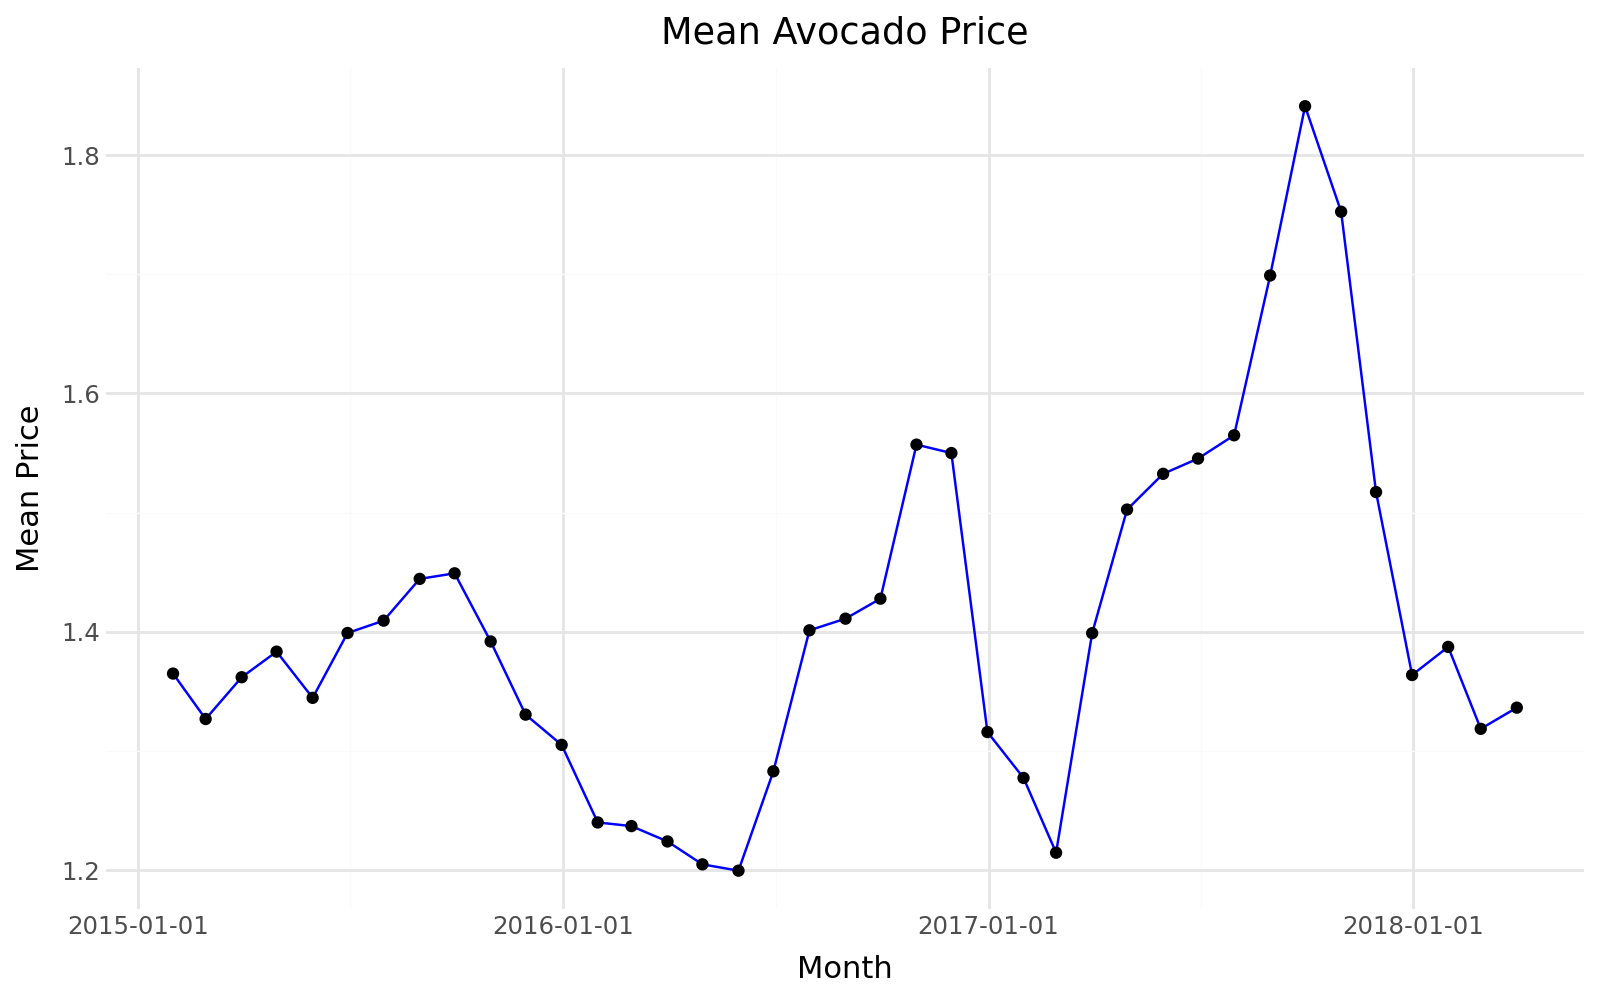

In [254]:
(ggplot(monthly_price, aes("monthly_price.index", "mean"))
+ geom_line(color="blue")
+ geom_point()
+ theme_minimal()
+ theme(figure_size = (8, 5)) 
+ labs(x = "Month",
      y = "Mean Price",
      title = "Mean Avocado Price"))

### Interpretation
The mean avocado price shows a clear upward trend from 2015 through a sharp peak in late 2017, followed by a steep decline. This spike likely reflects supply disruption or a surge in demand during that period. Prices are not flat or random they follow a pattern over time, which makes time series modelling a suitable approach for forecasting.

### Linearity

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\plotnine\stats\smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


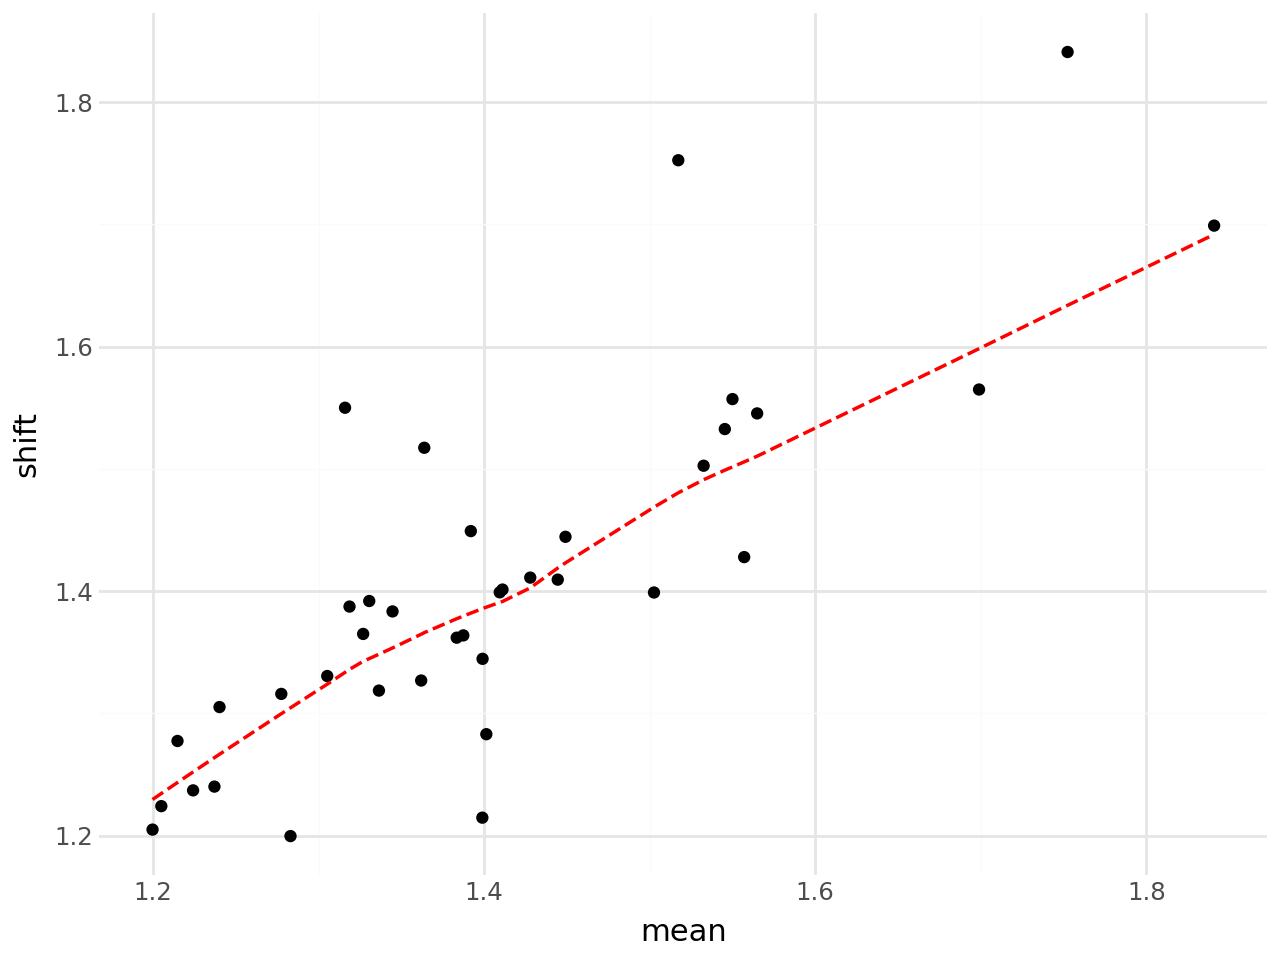

In [255]:
monthly_price["shift"] = monthly_price["mean"].shift(1)

(ggplot(monthly_price, aes("mean", "shift"))
+ geom_point()
+ geom_smooth(linetype = "--", size = 0.7, color = "red") 
+ theme_minimal())

# Interpretation
The lag plot shows a reasonably linear relationship between each monthly price and its value from the previous month. Points cluster along a diagonal, indicating that past prices are a good predictor of future prices. This confirms that an autoregressive model is appropriate for this dataset.

In [256]:
monthly_price.head()

,sum,mean,count,shift
date,,,,
2015-01-31,5307.30,1.365046,3888,NaN
2015-02-28,5159.16,1.326944,3888,1.365046
2015-03-31,6619.23,1.361981,4860,1.326944
2015-04-30,5378.85,1.383449,3888,1.361981
2015-05-31,6535.17,1.344685,4860,1.383449


### Stationarity

Null hypothesis: the dataset is non stationary

Alternative hypothesis: the dataset is stationary 

In [257]:
from statsmodels.tsa.stattools import adfuller

price2 = monthly_price[["mean"]]

price_adfuller = adfuller(price2)

pd.Series(price_adfuller[0:5], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', "Critical Value"])

Test Statistic                                                         -2.986463
p-value                                                                 0.036178
#Lags Used                                                                     1
Number of Observations Used                                                   37
Critical Value                 {'1%': -3.6209175221605827, '5%': -2.943539461...
dtype: object

### Interpretation
The p-value is <0.05, we reject the null hypothesis. The dataset is stationary

## Autocorrelation plot - ACF & PACF

In [258]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

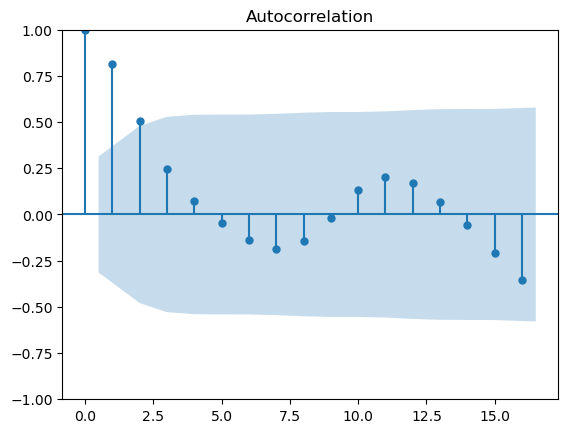

In [259]:
plot_acf(price2)

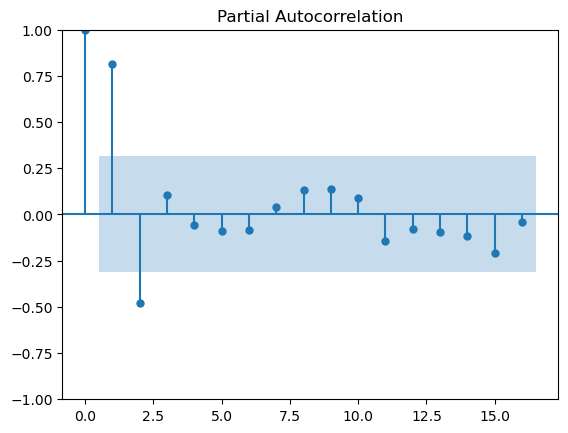

In [260]:
plot_pacf(price2)

### Interpretation
The PACF plot revealed that Autoregressive model AM(2) is a suitable model for this dataset.

### Decomposition

In [261]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

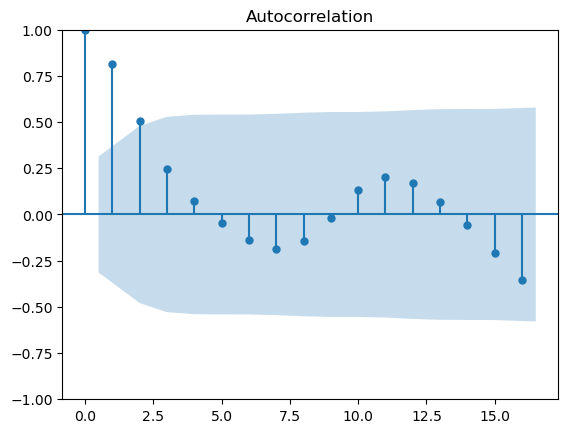

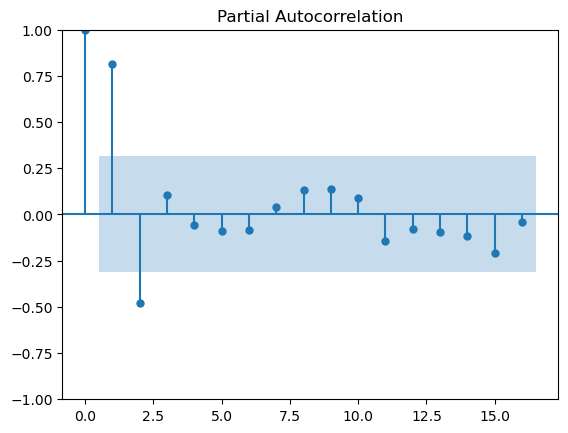

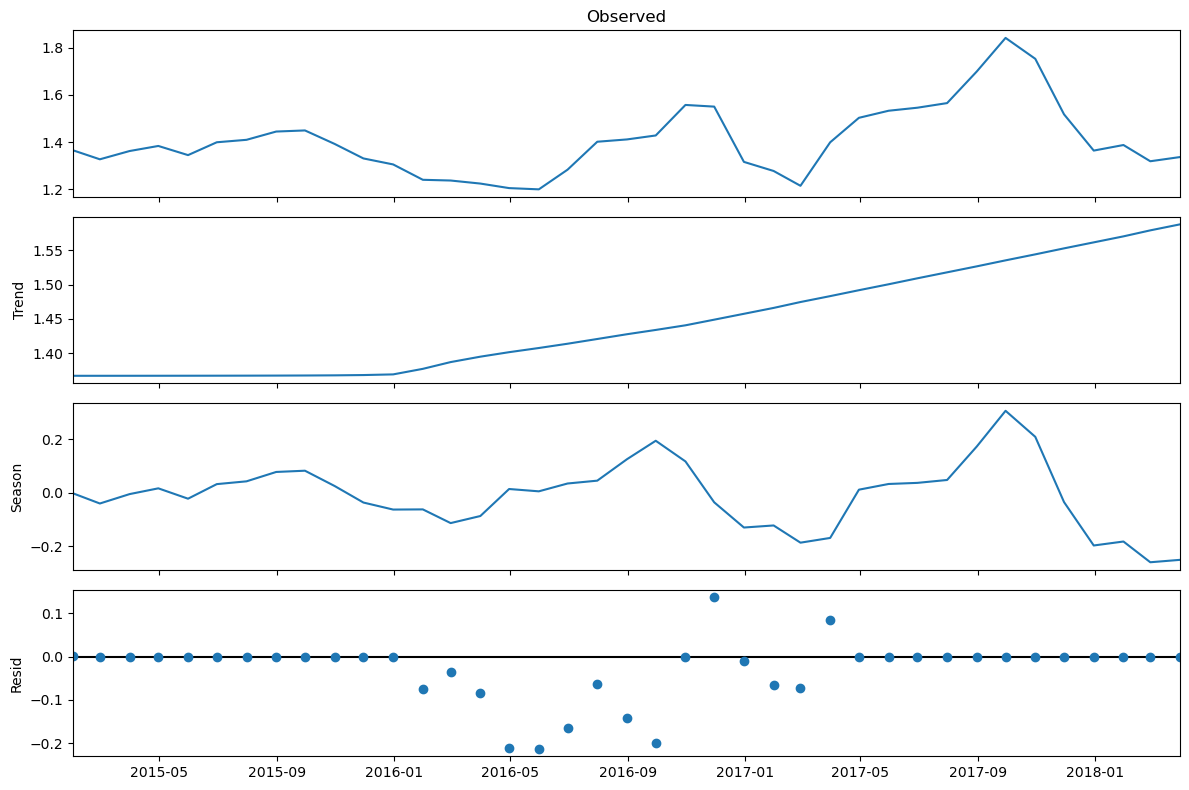

In [262]:
price_stl = STL(price2, period=12, robust=True)
price_res = price_stl.fit()
result = price_res.plot()

result.set_size_inches(12, 8)

result.tight_layout()

plt.show()

# Interpretation
The STL decomposition separates the price series into three components. The trend shows a steady price increase from 2015 into 2017, followed by a sharp spike and correction, consistent with what was observed in the line chart. The seasonal component reveals a clear repeating annual pattern, with prices rising mid-year and dipping in winter, aligning with the seasonal analysis findings. The residual component is relatively small and shows no obvious structure, suggesting that the trend and seasonal components have captured most of the meaningful variation in the data.

### Split and Train the data

In [263]:
monthly_price.tail(15)

,sum,mean,count,shift
date,,,,
2017-01-31,6208.65,1.277500,4860,1.315995
2017-02-28,4723.11,1.214792,3888,1.277500
2017-03-31,5439.06,1.398935,3888,1.214792
2017-04-30,7302.69,1.502611,4860,1.398935
2017-05-31,5958.72,1.532593,3888,1.502611
2017-06-30,5980.68,1.545395,3870,1.532593
2017-07-31,7605.54,1.564926,4860,1.545395
2017-08-31,6605.55,1.698958,3888,1.564926
2017-09-30,7157.61,1.840949,3888,1.698958


In [264]:
price2 = price2.sort_index()
price2_train = price2.loc[:"2017-07-31"]
price2_test = price2.loc["2017-08-31":]

### Model 1 - Time Series 

In [265]:
from statsmodels.tsa.arima.model import ARIMA
price_model = ARIMA(price2_train, order = (1,0,0))
price_ar = price_model.fit()

print(price_ar.summary())

                               SARIMAX Results                                
Dep. Variable:                   mean   No. Observations:                   31
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  37.901
Date:                Mon, 11 May 2026   AIC                            -69.802
Time:                        21:02:01   BIC                            -65.500
Sample:                    01-31-2015   HQIC                           -68.400
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3907      0.056     24.751      0.000       1.281       1.501
ar.L1          0.7751      0.132      5.877      0.000       0.517       1.034
sigma2         0.0049      0.001      3.343      0.0

### Model 2 - Time Series 

In [266]:
price_model2 = ARIMA(price2_train, order = (2,0,0))
price_ar2 = price_model2.fit()

print(price_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                   mean   No. Observations:                   31
Model:                 ARIMA(2, 0, 0)   Log Likelihood                  40.694
Date:                Mon, 11 May 2026   AIC                            -73.389
Time:                        21:02:01   BIC                            -67.653
Sample:                    01-31-2015   HQIC                           -71.519
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3806      0.036     38.487      0.000       1.310       1.451
ar.L1          1.0802      0.246      4.384      0.000       0.597       1.563
ar.L2         -0.4158      0.275     -1.511      0.1

### Model Evaluation

In [267]:
price_predict_train = price_ar.predict(start=price2_train.index[0],
                                 end=price2_train.index[-1],
                                 dynamic = False)

price_predict_train = price_predict_train.reset_index()
price_predict_train.head()

,date,predicted_mean
0,2015-01-31,1.390747
1,2015-02-28,1.370826
2,2015-03-31,1.341292
3,2015-04-30,1.368450
4,2015-05-31,1.385090


In [268]:
price2_train2 = price2_train.reset_index()
price_predict_train["mean"] = price2_train2["mean"]
price_predict_train.head()

,date,predicted_mean,mean
0,2015-01-31,1.390747,1.365046
1,2015-02-28,1.370826,1.326944
2,2015-03-31,1.341292,1.361981
3,2015-04-30,1.368450,1.383449
4,2015-05-31,1.385090,1.344685


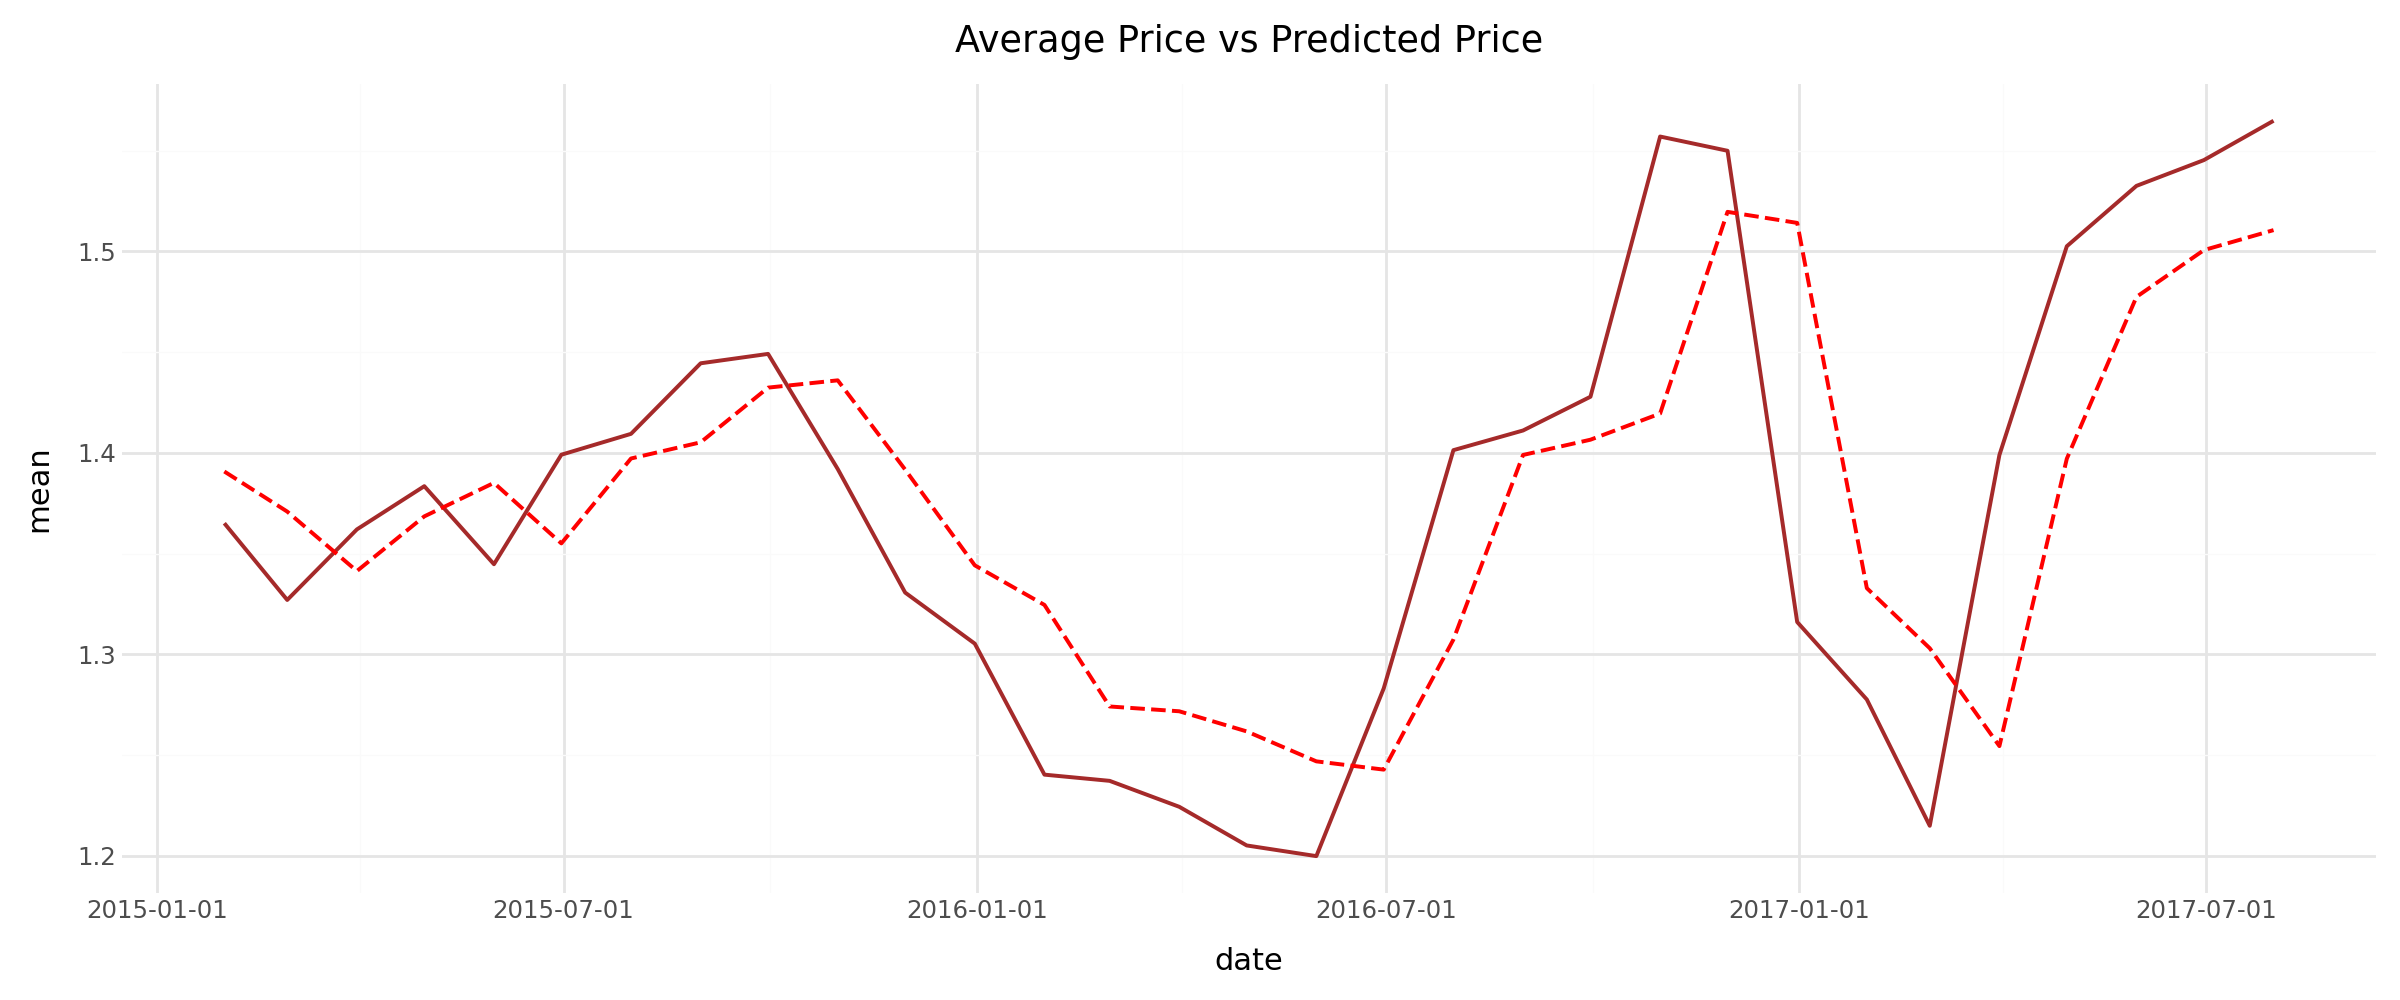

In [269]:
(ggplot(price_predict_train, aes("date", "mean"))
+ geom_line(color = "brown", size = 0.8)
+ geom_line(price_predict_train, aes("date", "predicted_mean"), color = "red", size = 0.8, linetype = "--") 
+ theme_minimal()
+ theme(figure_size = (12, 5))
+ labs(title = "Average Price vs Predicted Price"))

In [270]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [271]:
mse_t = mean_squared_error(price_predict_train["mean"], price_predict_train["predicted_mean"])

In [272]:
rmse_t = np.sqrt(mse_t)
rmse_t

np.float64(0.07029373566265786)

### Linear regression model RMSE is 0.255045, while Time series model RMSE is 0.07. Therefore, the time series model with the lower RMSE is a better model

## Predicting on unseen  data - Time Series Analysis

In [273]:
price_predict = price_ar.predict(start=price2_test.index[0],
                                 end=price2_test.index[-1],
                                 dynamic = False)

price_predict = price_predict.reset_index()
price_predict.head()

,index,predicted_mean
0,2017-08-31,1.525758
1,2017-09-30,1.495398
2,2017-10-31,1.471865
3,2017-11-30,1.453624
4,2017-12-31,1.439485


In [274]:
price2_test

,mean
date,
2017-08-31,1.698958
2017-09-30,1.840949
2017-10-31,1.752444
2017-11-30,1.517292
2017-12-31,1.363852
2018-01-31,1.387431
2018-02-28,1.318704
2018-03-31,1.336458


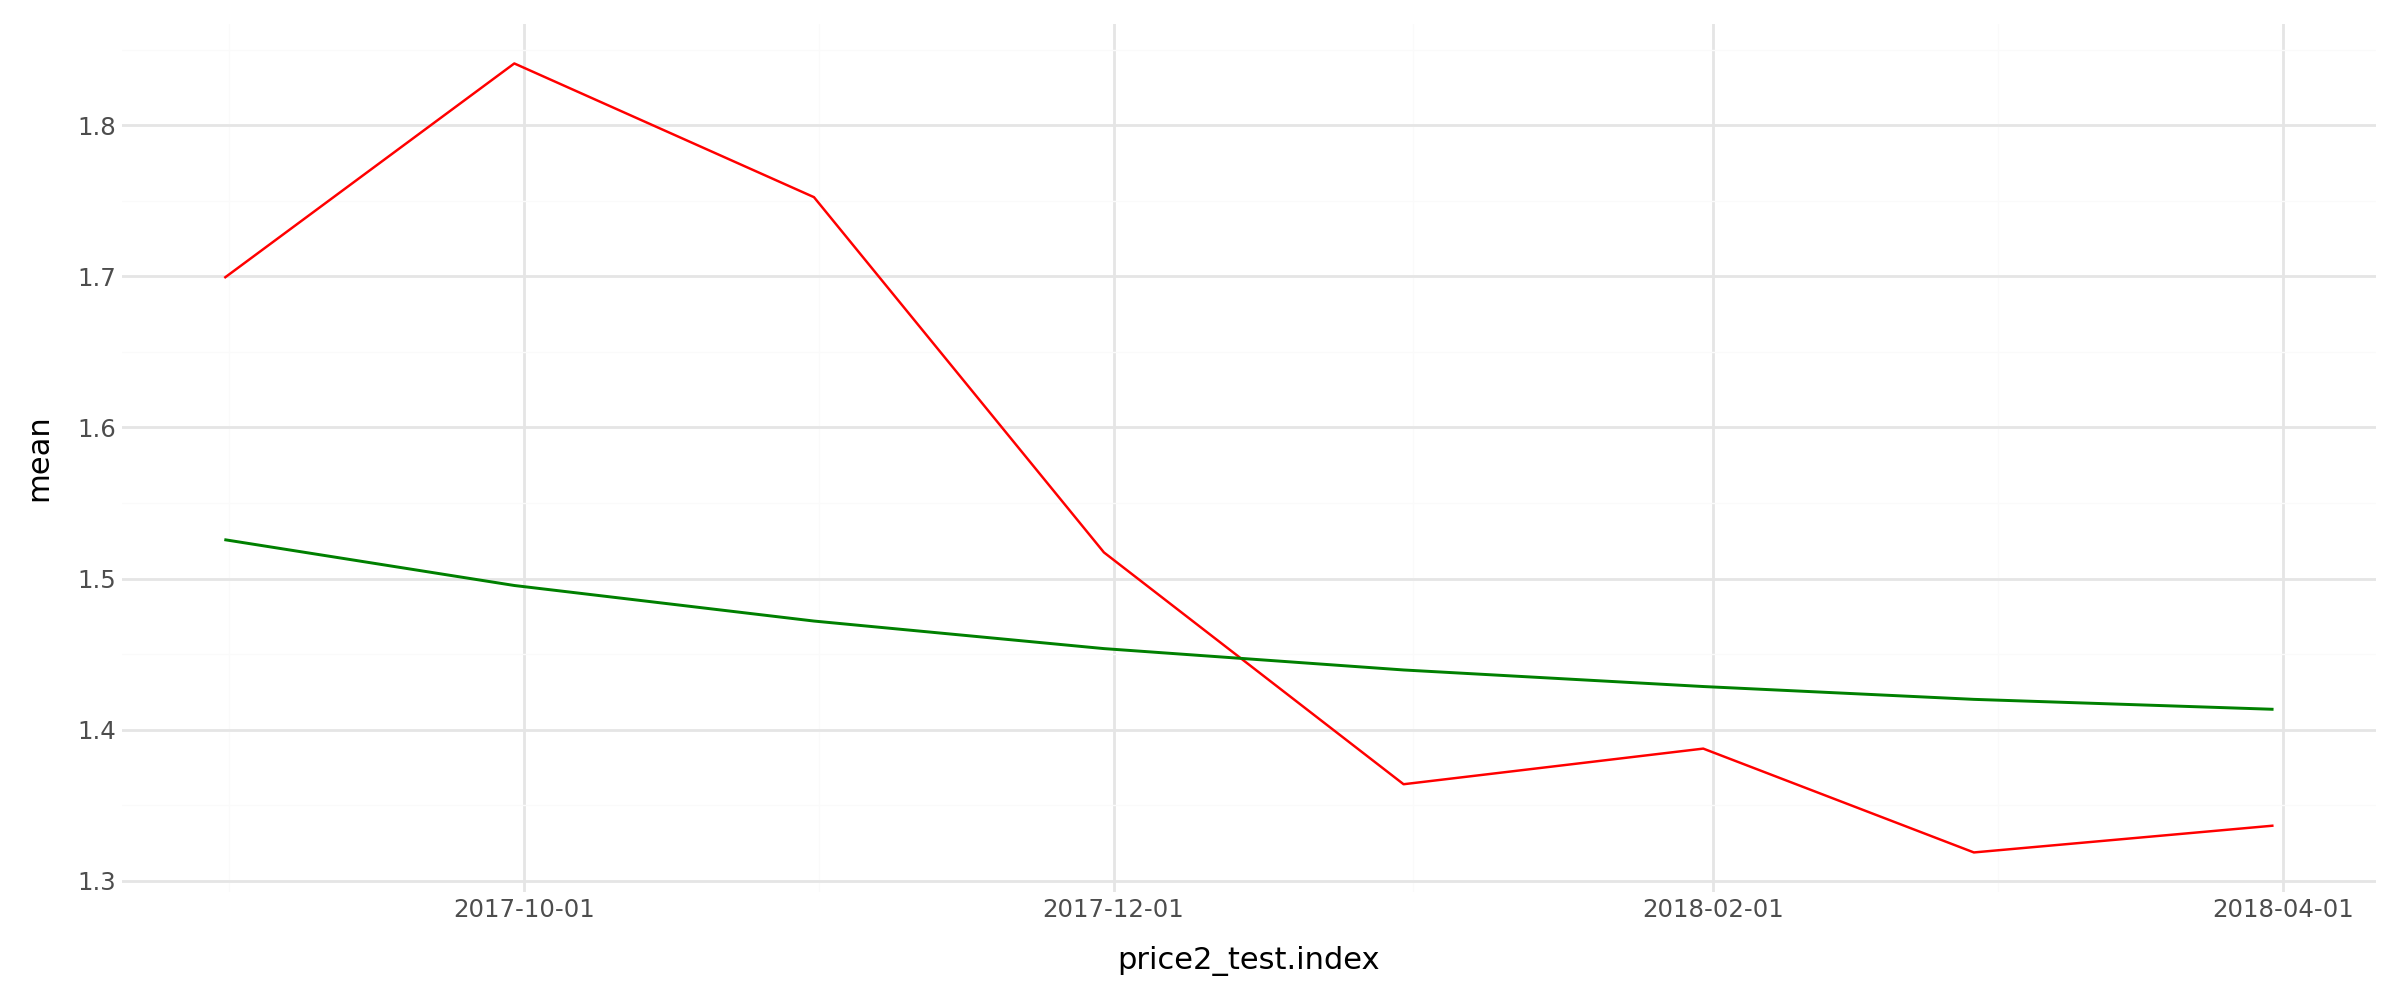

In [275]:
(ggplot(price2_test, aes("price2_test.index", "mean"))
+ geom_line( color = "red") 
+ geom_line(price_predict, aes("index", "predicted_mean"), color = "green", size = 0.6) 
+ theme_minimal()
+ theme(figure_size = (12, 5)))

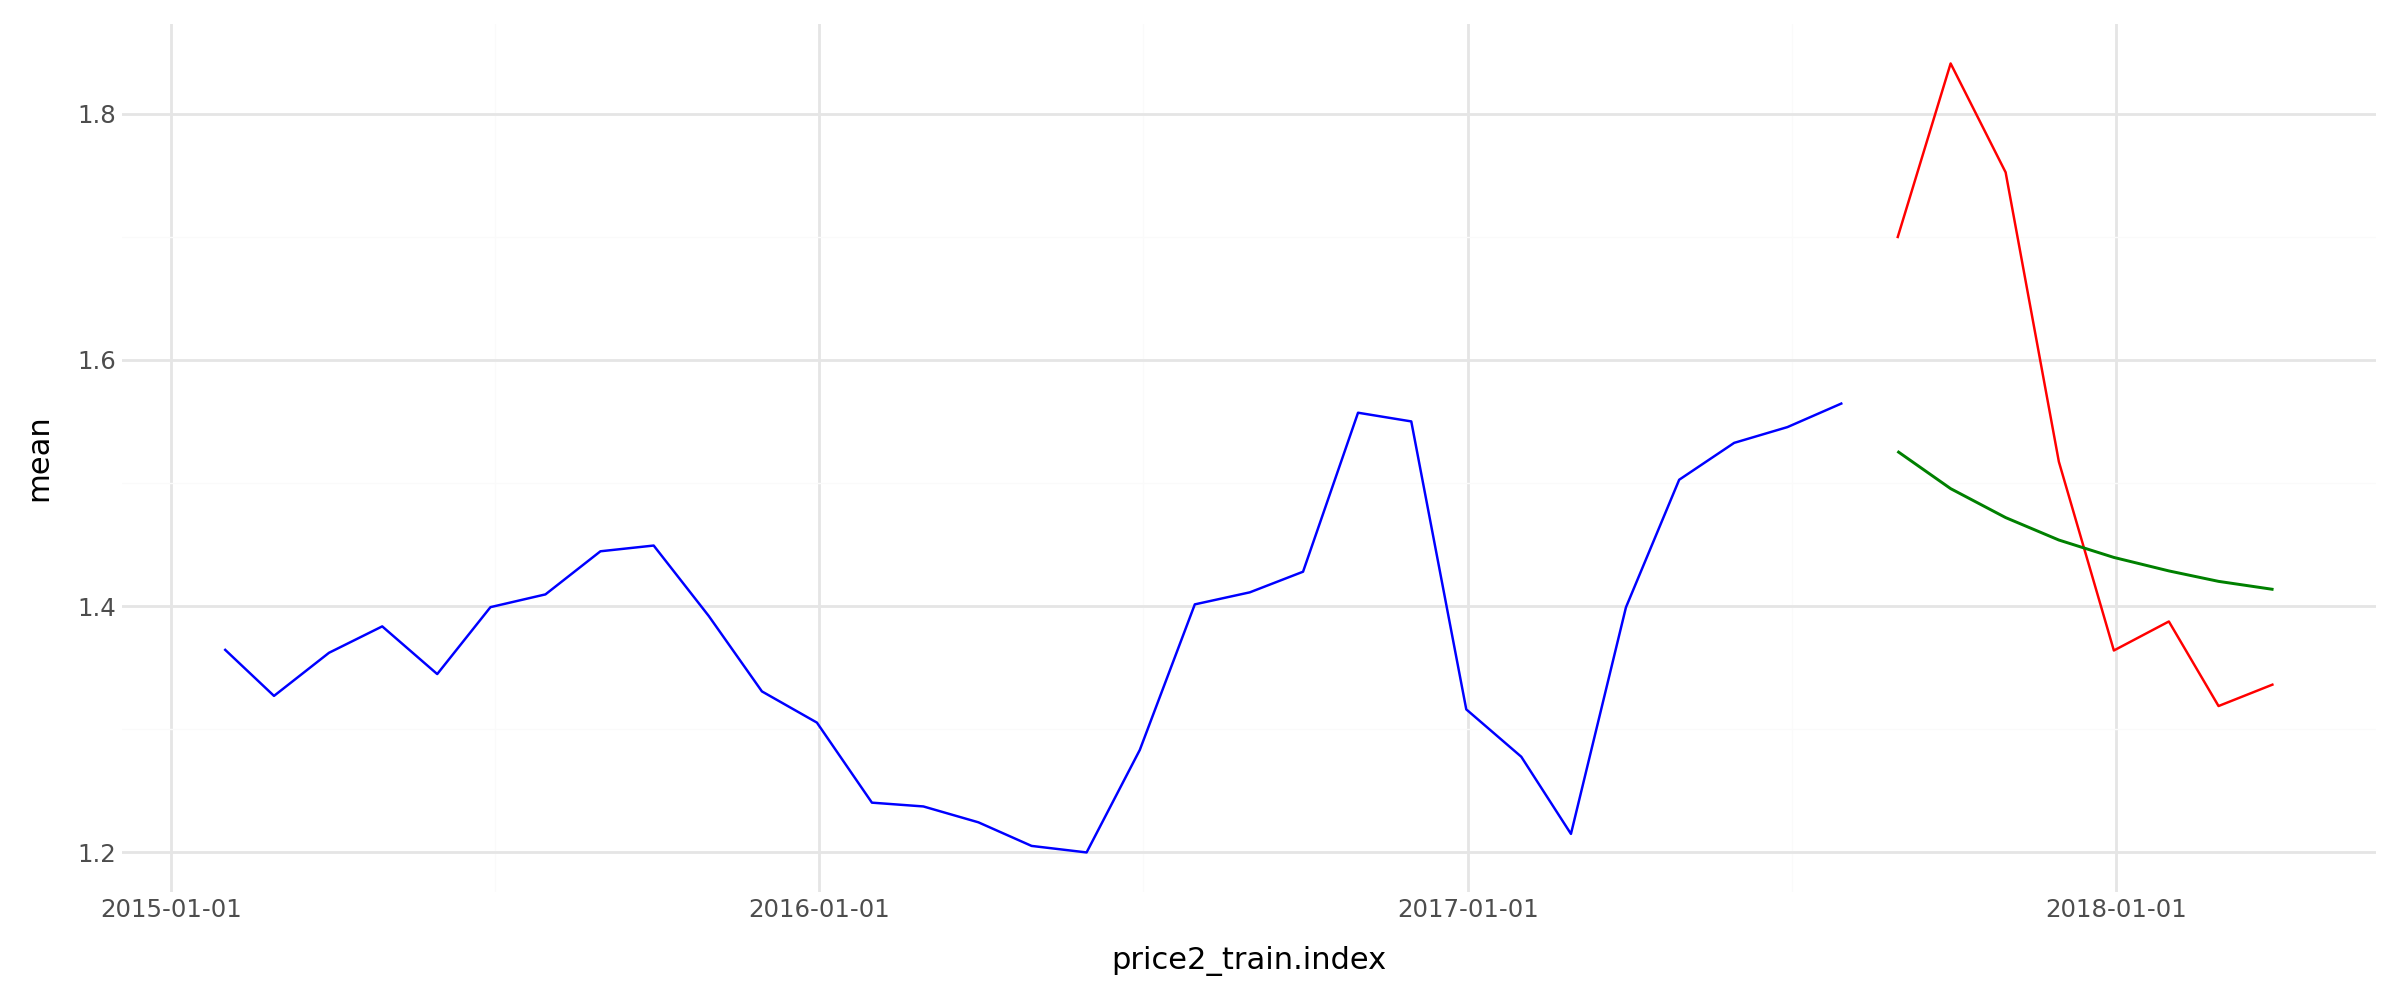

In [276]:
(ggplot(price2_train, aes("price2_train.index", "mean"))
+ geom_line(color = "blue")
+ geom_line(price2_test, aes("price2_test.index", "mean"), color = "red") 
+ geom_line(price_predict, aes("index", "predicted_mean"), color = "green", size = 0.6) 
+ theme_minimal()
+ theme(figure_size = (12, 5)))


In [277]:
price2_test2 = price2_test.reset_index()

price_predict["mean"] = price2_test2["mean"]
price_predict.head()

,index,predicted_mean,mean
0,2017-08-31,1.525758,1.698958
1,2017-09-30,1.495398,1.840949
2,2017-10-31,1.471865,1.752444
3,2017-11-30,1.453624,1.517292
4,2017-12-31,1.439485,1.363852


### Residuals

In [278]:
price_predict["residuals"] = price_predict["mean"] - price_predict["predicted_mean"]

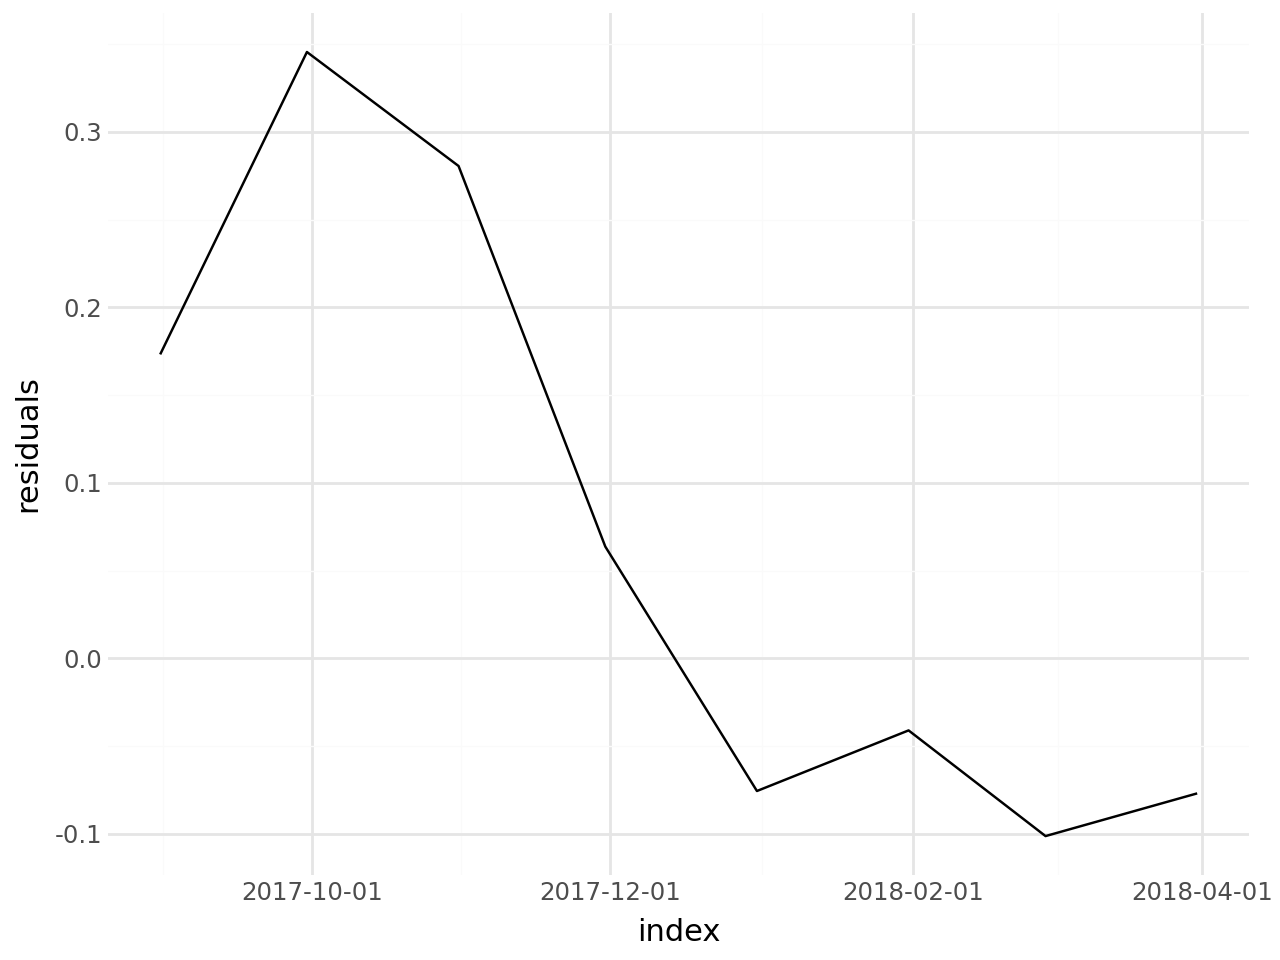

In [279]:
(ggplot(price_predict, aes("index", "residuals"))
+ geom_line()
+ theme_minimal() 
) 

### ACF of residuals

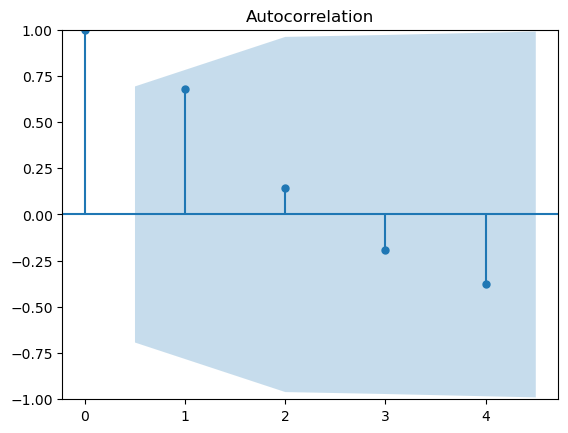

In [280]:
plot_acf(price_predict["residuals"])

### Evaluation Result

In [281]:
mse_pred = mean_squared_error(price_predict["mean"], price_predict["predicted_mean"])

In [282]:
rmse_pred = np.sqrt(mse_pred)
rmse_pred

np.float64(0.1788104535724331)

# Interpretation
The AR(1) model generalises well to unseen data, achieving a test RMSE of 0.179. This is lower than the linear regression RMSE of 0.255, confirming that the time series model is the better approach for predicting avocado prices over time. This is expected because price in a market naturally depends on what prices were in the previous period, which autoregressive models are designed to capture.
The residual plot shows errors scattered randomly around zero with no clear pattern, meaning the model has captured the main structure in the data and is not systematically over or under-predicting. The ACF of the residuals shows no significant autocorrelation at any lag, confirming the model is well specified and no predictable signal has been left unexploited.
Overall, the time series approach outperforms linear regression for price forecasting. However, since the model was trained on nationally aggregated monthly prices without separating by region or avocado type, predictions represent a broad market average and will be less precise for specific markets or product categories.

# Part 2: Avocado Type Classification
### Objective: Classify avocados as Organic or Conventional using Logistic Regression or PCA
#### Option A: Logistic Regression - Encode target variable (Organic = 1, Conventional = 0) 
+ Train Logistic Regression model - Evaluate using accuracy, confusion matrix, precision, and recall

In [283]:
avocado.head()

,date,average_price,total_volume,total_bags,type,year,region,plu_code,plu_volume,bag_type,bag_volume,month,day,season,type_encoded,broad_region
0,2015-12-27,1.33,64236.62,8696.87,conventional,2015,Albany,4046,1036.74,small bags,8603.62,12,27,Winter,0,Northeast
1,2015-12-20,1.35,54876.98,9505.56,conventional,2015,Albany,4046,674.28,small bags,9408.07,12,20,Winter,0,Northeast
2,2015-12-13,0.93,118220.22,8145.35,conventional,2015,Albany,4046,794.70,small bags,8042.21,12,13,Winter,0,Northeast
3,2015-12-06,1.08,78992.15,5811.16,conventional,2015,Albany,4046,1132.00,small bags,5677.40,12,6,Winter,0,Northeast
4,2015-11-29,1.28,51039.60,6183.95,conventional,2015,Albany,4046,941.48,small bags,5986.26,11,29,Fall,0,Northeast


In [284]:
# Encode the target
# organic = 1, conventional = 0
avocado['type_encoded'] = (avocado['type'] == 'organic').astype(int)


avocado[['type', 'type_encoded']].value_counts()

type          type_encoded
conventional  0               82134
organic       1               82107
Name: count, dtype: int64

In [285]:
# features (X) 
# target (y)
# X = numeric features only 
x_logit = avocado[['average_price', 'total_volume', 'total_bags', 'month', 'year']]
y_logit = avocado['type_encoded']

print('x shape:', x_logit.shape)
print('y_logit value counts:')
print(y_logit.value_counts())

x shape: (164241, 5)
y_logit value counts:
type_encoded
0    82134
1    82107
Name: count, dtype: int64


In [286]:
# Train/test split
from sklearn.model_selection import train_test_split

x_train_logit, x_test_logit, y_train_logit, y_test_logit = train_test_split(
    x_logit, y_logit, test_size=0.2, random_state=42)

print('Training set:', x_train_logit.shape)
print('Test set:    ', x_test_logit.shape)

Training set: (131392, 5)
Test set:     (32849, 5)


In [287]:
x_train_logit.head()

,average_price,total_volume,total_bags,month,year
121140,1.92,4163.22,613.16,7,2015
90178,1.48,79396.08,65490.10,12,2017
83085,1.22,11429.63,1296.67,6,2015
149581,1.11,2791515.27,851394.28,12,2016
46882,1.51,901.53,880.00,10,2015


In [288]:
x_test_logit.head()

,average_price,total_volume,total_bags,month,year
116022,1.58,236604.19,51819.25,10,2017
96168,1.01,529817.53,56258.79,4,2016
45069,1.11,331324.99,172049.38,1,2018
30774,1.12,32688.03,21245.27,8,2016
131758,1.15,78262.36,39414.77,10,2016


In [289]:
# Standardization to put all the value in the same scale
from sklearn.preprocessing import StandardScaler
#calling up the standard scaler
scaler = StandardScaler()

In [290]:
#fitting our data into the standard scaler
x_logit_standard_scaled = scaler.fit(x_train_logit)                        

x_logit_standard_scaled

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [291]:
# Transforming our data
x_train_logit_scaled = scaler.transform(x_train_logit)  

x_test_logit_scaled  = scaler.transform(x_test_logit)   

x_train_logit_scaled

array([[ 1.27849378, -0.24548033, -0.24262728,  0.23285868, -1.22128168],
       [ 0.18513346, -0.2236695 , -0.17676418,  1.64809765,  0.904921  ],
       [-0.46094309, -0.24337372, -0.24193338, -0.05018911, -1.22128168],
       ...,
       [-1.30581243, -0.18193024, -0.17350601, -0.05018911, -0.15818034],
       [-0.83367957, -0.17974305, -0.17484602, -0.89933249, -1.22128168],
       [-0.93307596, -0.24208641, -0.23207573,  1.08200206, -0.15818034]])

In [292]:
# putting them in a dataframe

x_train_logit_scaled_df = pd.DataFrame(x_train_logit_scaled, columns=x_train_logit.columns)
x_test_logit_scaled_df  = pd.DataFrame(x_test_logit_scaled,  columns=x_test_logit.columns)

x_train_logit_scaled_df.head()

,average_price,total_volume,total_bags,month,year
0,1.278494,-0.245480,-0.242627,0.232859,-1.221282
1,0.185133,-0.223670,-0.176764,1.648098,0.904921
2,-0.460943,-0.243374,-0.241933,-0.050189,-1.221282
3,-0.734283,0.562604,0.621086,1.648098,-0.158180
4,0.259681,-0.246426,-0.242356,1.082002,-1.221282


In [293]:
x_test_logit_scaled_df.head()

,average_price,total_volume,total_bags,month,year
0,0.433624,-0.178093,-0.190643,1.082002,0.904921
1,-0.982774,-0.093087,-0.186136,-0.616285,-0.158180
2,-0.734283,-0.150633,-0.068585,-1.465428,1.968022
3,-0.709434,-0.237211,-0.221682,0.515906,-0.158180
4,-0.634887,-0.223998,-0.203236,1.082002,-0.158180


In [294]:
# Train the model
from sklearn.linear_model import LogisticRegression

type_model = LogisticRegression()

type_model.fit(x_train_logit_scaled_df, y_train_logit) #fit our model with the feature and target

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [295]:
type_model.intercept_

array([-8.29017489])

In [296]:
type_model.coef_

array([[  1.84624213, -67.39881708,  27.32112805,  -0.46870845,
         -0.35648785]])

In [297]:
#tidying it up
type_coef_df = pd.DataFrame(type_model.coef_.T, x_train_logit_scaled_df.columns, columns = ['coefficient'])
type_coef_df

,coefficient
average_price,1.846242
total_volume,-67.398817
total_bags,27.321128
month,-0.468708
year,-0.356488


The results above are in log odd
#### conventional : 0
#### organic : 1
+ As the price goes up, the Log odd for the avocado being organic increases
+ As the volume goes up, the Log odd for the avocado being organic decreases
+ As the total bags goes up, the Log odd for the avocado being organic increases
+ As the month progresses, the Log odd for the avocado being organic decreases
+ As the year progresses, the Log odd for the avocado being organic decreases

In [298]:
#transforming our coefficients into odds from log odd
import numpy as np
type_coef_df = pd.DataFrame(np.exp(type_model.coef_),  columns = x_train_logit_scaled_df.columns)
type_coef_df

,average_price,total_volume,total_bags,month,year
0,6.335965,5.358777e-30,7.335254e+11,0.62581,0.700131


### Interpretation
 greater than 1 (>1) means the chances of it being organic is higher

< 1 decreases the chance of it being organic

+ Average price (odds ratio = 6):avocados are 6 times more likely to be organic at higher price points.
+ Higher volume decreases the odds of being organic. Conventional avocados dominate market sales while organic supply is more limited.

### Predicting on training data

In [299]:
y_train_logit_pred = type_model.predict(x_train_logit_scaled_df)

In [300]:
from sklearn import metrics
print(metrics.classification_report(y_train_logit, y_train_logit_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     65729
           1       0.90      0.94      0.92     65663

    accuracy                           0.92    131392
   macro avg       0.92      0.92      0.92    131392
weighted avg       0.92      0.92      0.92    131392



### Interpretation

The model achieves 92% accuracy on training data. Precision of 90% means that when the model predicts organic, it is right 90% of the time. Recall of 94% means the model correctly identifies 94% of all actual organic avocados. These are strong results, showing the model has learned to reliably separate organic from conventional avocados.

### Confusion Matrix

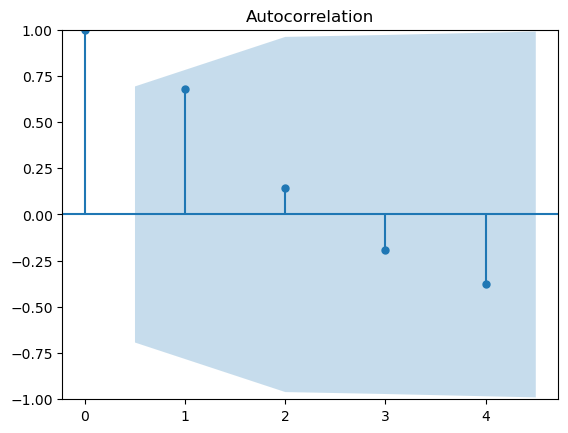

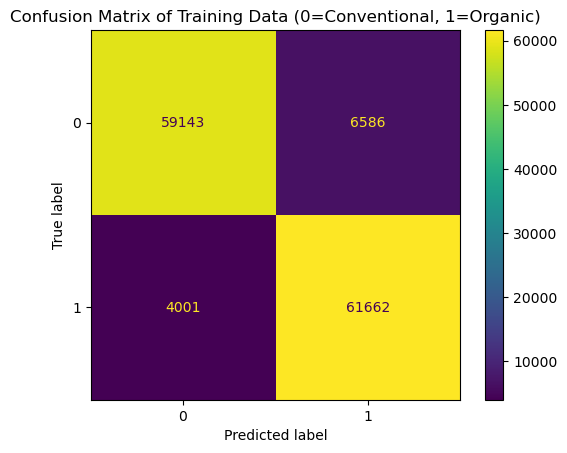

In [301]:
# Confusion matrix 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_train_logit, y_train_logit_pred)
plt.title('Confusion Matrix of Training Data (0=Conventional, 1=Organic)')
plt.show()

+ True negatives : 59062
+ False positives: 6569
+ False Negatives: 3949
+ True Positives: 61812

From our prediction, 61812 got the prediction on our avocado being organic right 

Where it was actually conventional and the data was saying organic: 6569

Where the model was saying conventional while it was organic: 3949


### Option B: Principal Component Analysis

In [302]:
avocado.columns

Index(['date', 'average_price', 'total_volume', 'total_bags', 'type', 'year',
       'region', 'plu_code', 'plu_volume', 'bag_type', 'bag_volume', 'month',
       'day', 'season', 'type_encoded', 'broad_region'],
      dtype='object')

In [303]:
region_map = {
    'Northeast': ['Albany', 'BaltimoreWashington', 'Boston', 'BuffaloRochester', 'HarrisburgScranton', 
                  'HartfordSpringfield', 'NewYork', 'Philadelphia', 'Pittsburgh', 'Syracuse', 'NorthernNewEngland'],
    
    'Southeast': ['Atlanta', 'Charlotte', 'Jacksonville', 'MiamiFtLauderdale', 'Nashville', 
                  'NewOrleansMobile', 'Orlando', 'RaleighGreensboro', 'RichmondNorfolk', 'Roanoke', 
                  'SouthCarolina', 'Tampa', 'Louisville'],
    
    'Midwest': ['Chicago', 'CincinnatiDayton', 'Columbus', 'Detroit', 'GrandRapids', 'Indianapolis', 'StLouis'],
    
    'West': ['Boise', 'California', 'Denver', 'LasVegas', 'LosAngeles', 'PhoenixTucson', 'Portland', 
             'Sacramento', 'SanDiego', 'SanFrancisco', 'Seattle', 'Spokane', 'WestTexNewMexico'],
    
    'SouthCentral': ['DallasFtWorth', 'Houston']
}

# Invert the dictionary for mapping
city_to_region = {city: region for region, cities in region_map.items() for city in cities}

# Apply the mapping to create a new column
avocado3 = avocado
avocado3['broad_region'] = avocado['region'].map(city_to_region)
avocado3.head()

,date,average_price,total_volume,total_bags,type,year,region,plu_code,plu_volume,bag_type,bag_volume,month,day,season,type_encoded,broad_region
0,2015-12-27,1.33,64236.62,8696.87,conventional,2015,Albany,4046,1036.74,small bags,8603.62,12,27,Winter,0,Northeast
1,2015-12-20,1.35,54876.98,9505.56,conventional,2015,Albany,4046,674.28,small bags,9408.07,12,20,Winter,0,Northeast
2,2015-12-13,0.93,118220.22,8145.35,conventional,2015,Albany,4046,794.70,small bags,8042.21,12,13,Winter,0,Northeast
3,2015-12-06,1.08,78992.15,5811.16,conventional,2015,Albany,4046,1132.00,small bags,5677.40,12,6,Winter,0,Northeast
4,2015-11-29,1.28,51039.60,6183.95,conventional,2015,Albany,4046,941.48,small bags,5986.26,11,29,Fall,0,Northeast


In [304]:
avocado3.columns 

Index(['date', 'average_price', 'total_volume', 'total_bags', 'type', 'year',
       'region', 'plu_code', 'plu_volume', 'bag_type', 'bag_volume', 'month',
       'day', 'season', 'type_encoded', 'broad_region'],
      dtype='object')

In [305]:
independent_var2 = avocado3[['average_price', 'total_volume', 'plu_volume', 'total_bags', 'bag_volume', 'broad_region', 'season', 'plu_code']]
dependent_var2 = avocado3['type_encoded']

x_train2, x_test2, y_train2, y_test2 = train_test_split(independent_var2, dependent_var2, test_size=0.2, random_state=42)

In [306]:
x_train2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131392 entries, 121140 to 121958
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   average_price  131392 non-null  float64
 1   total_volume   131392 non-null  float64
 2   plu_volume     131392 non-null  float64
 3   total_bags     131392 non-null  float64
 4   bag_volume     131392 non-null  float64
 5   broad_region   111972 non-null  object 
 6   season         131392 non-null  object 
 7   plu_code       131392 non-null  object 
dtypes: float64(5), object(3)
memory usage: 9.0+ MB


In [307]:
num_cols = x_train2[['plu_volume', 'total_volume', 'total_bags', 'bag_volume', 'average_price']]
num_cols_test = x_test2[['plu_volume', 'total_volume', 'total_bags', 'bag_volume', 'average_price']]
cat_cols = x_train2[['plu_code', 'season', 'broad_region']]
cat_cols_test = x_test2[['plu_code', 'season', 'broad_region']]

In [308]:
cat_cols = pd.get_dummies(cat_cols, columns = ['plu_code', 'season', 'broad_region'], drop_first=True, dtype=int).reset_index(drop=True)
cat_cols_test = pd.get_dummies(cat_cols_test, columns = ['plu_code', 'season', 'broad_region'], drop_first=True, dtype=int).reset_index(drop=True)

In [309]:
print(cat_cols.shape)
print(cat_cols_test.shape)

(131392, 9)
(32849, 9)


In [310]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(num_cols)
X_train_num = pd.DataFrame(X_train_num, columns=num_cols.columns).reset_index(drop=True)

X_test_num = scaler.transform(num_cols_test)
X_test_num = pd.DataFrame(X_test_num, columns=num_cols.columns).reset_index(drop=True)

In [311]:
X_train2_scaled_df = pd.concat([X_train_num, cat_cols], axis=1)
X_test2_scaled_df = pd.concat([X_test_num, cat_cols_test], axis=1)
X_test2_scaled_df.shape

(32849, 14)

In [312]:
from sklearn.decomposition import PCA

# Fit a PCA model with no n_components to the scaled training data
pca= PCA()
X_pca = pca.fit(X_train2_scaled_df)

# Call the PCA transformed data X_train_scaled_trans
X_train_scaled_trans = X_pca.transform(X_train2_scaled_df)

X_train_scaled_trans = pd.DataFrame(X_train_scaled_trans, columns=X_train2_scaled_df.columns)

X_train_scaled_trans

,plu_volume,total_volume,total_bags,bag_volume,average_price,plu_code_4225,plu_code_4770,season_Spring,season_Summer,season_Winter,broad_region_Northeast,broad_region_SouthCentral,broad_region_Southeast,broad_region_West
0,-0.599147,1.256984,-0.059372,0.018779,-0.038424,-0.000070,0.732515,0.041394,0.106925,-0.469529,-0.371764,0.257914,0.013492,-0.147994
1,-0.373639,0.063277,-0.151088,-0.639222,0.728945,0.029801,-0.308103,-0.289398,-0.076973,0.210304,-0.361619,0.196906,-0.022744,-0.162930
2,-0.346623,-0.474263,-0.149966,-0.643056,-0.105518,0.036787,0.863990,-0.284707,0.308072,0.212598,-0.650282,0.186444,0.041749,0.746270
3,0.643858,-0.732505,0.038300,0.907186,0.701463,0.010583,-0.268270,-0.351982,-0.006136,0.185612,-0.281720,0.144031,-0.030237,-0.160883
4,-0.488944,0.179213,0.195914,0.614567,-0.023323,-0.717063,0.102888,0.221516,-0.401331,0.255093,0.077471,-0.439326,-0.028029,0.018908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131387,-0.479794,0.182175,-0.001442,-0.029242,-0.020295,-0.700989,0.107609,0.063319,-0.406247,-0.465641,0.077708,-0.440564,0.012795,0.016326
131388,-0.418914,-0.095301,0.207943,0.622159,0.721057,-0.016464,-0.307628,0.233139,-0.031264,0.254886,-0.357153,0.189650,-0.033892,-0.166883
131389,-0.175061,-1.286661,-0.124665,-0.653773,-0.144153,-0.656354,1.003040,-0.322619,-0.072559,0.210784,0.240733,0.049093,-0.004883,-0.008602
131390,-0.258064,-0.803166,0.204143,0.634988,-0.671611,-0.027829,-0.569680,0.137340,0.850313,0.250410,0.267452,0.038026,-0.035829,0.005481


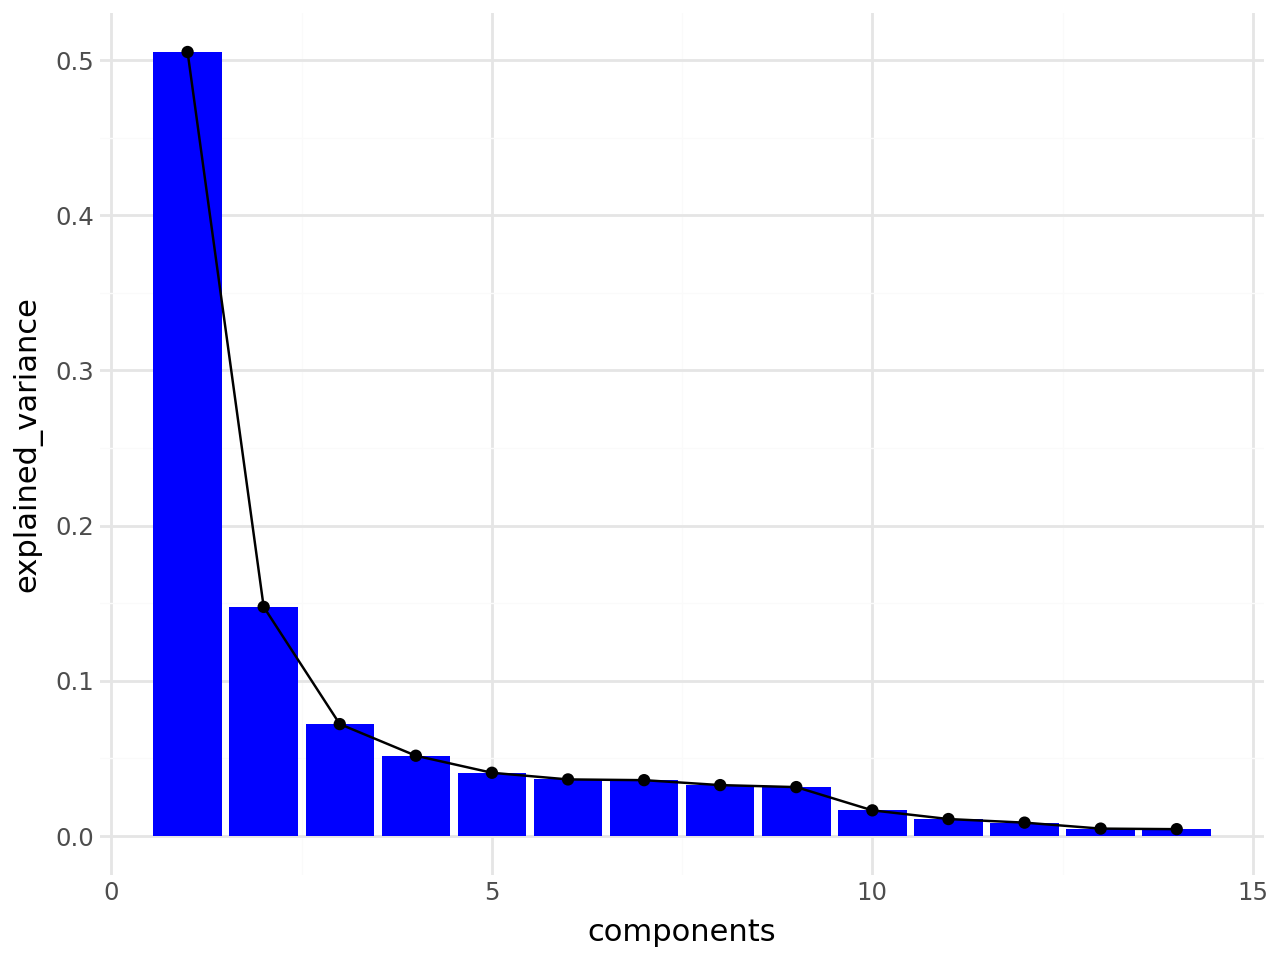

In [313]:
# Get the percentage of variance explained by each component
explained_variance = pca.explained_variance_ratio_

explained_variance_df = pd.DataFrame({"components": range(1, 15),
             "explained_variance": explained_variance})



# Get the eigenvalues (optional, for an alternative plot)
eigenvalues = pca.explained_variance_

# Make a Scree plot
(ggplot(explained_variance_df, aes("components", "explained_variance"))
+ geom_col(fill = "blue")
+ geom_line()
+ geom_point()
+ theme_minimal())

In [314]:
explained_variance_df.head()

,components,explained_variance
0,1,0.505156
1,2,0.147668
2,3,0.072152
3,4,0.051770
4,5,0.040790


In [315]:
top3 = explained_variance_df.head(3)
top3["explained_variance"].sum()

np.float64(0.7249754979667917)

#### The optimal number of principal components to be retained in my analysis is 3.

#### Based on the scree plot, the first three components represent the "elbow" of the curve, capturing the most significant signal. Also, the first three components account for 72.5% of the variance.

In [316]:
loadings = pd.DataFrame(pca.components_.T, columns = [f'PC{i+1}' for i in range(len(X_train2_scaled_df.columns))], index = X_train2_scaled_df.columns)
print(loadings)

                                PC1       PC2       PC3       PC4       PC5  \
plu_volume                 0.476112  0.060128 -0.554297 -0.104445  0.003174   
total_volume               0.530154  0.055290 -0.136256  0.194706  0.001202   
total_bags                 0.525051  0.071168 -0.021189  0.186698  0.007598   
bag_volume                 0.441554  0.102338  0.781453 -0.317980 -0.006404   
average_price             -0.141754  0.977611 -0.034795  0.016858  0.035654   
plu_code_4225              0.005074  0.002817 -0.151878 -0.631456 -0.000935   
plu_code_4770             -0.009376 -0.003077  0.195811  0.644629 -0.003008   
season_Spring              0.003665 -0.041012  0.001481 -0.005691 -0.667144   
season_Summer             -0.001517  0.049057 -0.008504  0.010888 -0.067736   
season_Winter              0.006177 -0.086608  0.013047 -0.008073  0.739080   
broad_region_Northeast    -0.024157  0.089476 -0.005861 -0.001778  0.043944   
broad_region_SouthCentral -0.000119 -0.033675  0.000

In [317]:
loadings['PC1'].abs().sort_values(ascending=False).head(3)

total_volume    0.530154
total_bags      0.525051
plu_volume      0.476112
Name: PC1, dtype: float64

In [318]:
loadings['PC2'].abs().sort_values(ascending=False).head(3)

average_price             0.977611
bag_volume                0.102338
broad_region_Northeast    0.089476
Name: PC2, dtype: float64

In [319]:
loadings['PC3'].abs().sort_values(ascending=False).head(3)

bag_volume       0.781453
plu_volume       0.554297
plu_code_4770    0.195811
Name: PC3, dtype: float64

## Interpretation
The PCA results indicate that the model's structure is primarily driven by specific feature, with avocado volume, and average price serving as the most significant contributors to the PC1, PC2 and PC3. These high loadings suggest that these specific features contain the most critical information used by the model to differentiate between the classes.

In [320]:
pca_2 = PCA(n_components = 3)
pca_2.fit(X_train2_scaled_df)
X_pca2_transform = pca_2.transform(X_train2_scaled_df)
X_pca2_transform

array([[-0.59914672,  1.2569837 , -0.05937199],
       [-0.37363862,  0.0632766 , -0.15108824],
       [-0.34662253, -0.47426277, -0.14996567],
       ...,
       [-0.17506093, -1.28666119, -0.12466537],
       [-0.2580644 , -0.80316587,  0.20414345],
       [-0.27717317, -0.953239  ,  0.02583994]])

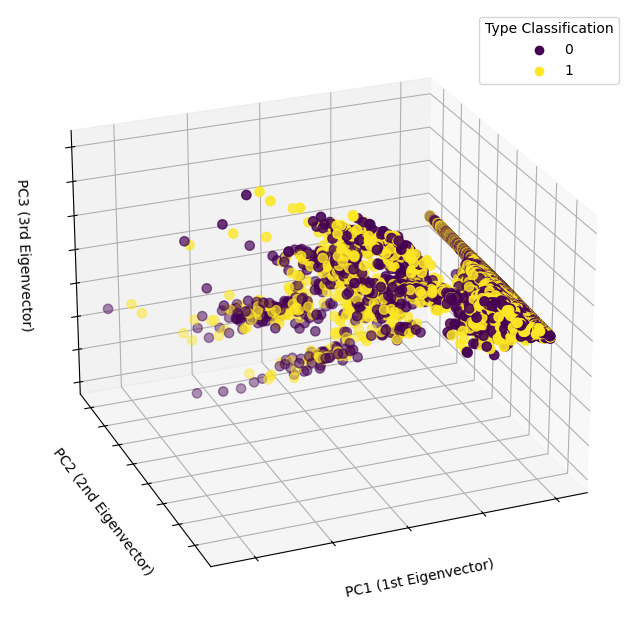

In [321]:
Xpca_df = pd.DataFrame({"pca_1": X_pca2_transform[:, 0],
                        "pca_2": X_pca2_transform[:, 1],
                        "pca_3": X_pca2_transform[:, 2]})

Xpca_df["type_encoded"] = avocado3["type_encoded"]

# Create a scatter plot and colour by the features
fig = plt.figure(1, figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d", elev=-155, azim=112)
labels = sorted(Xpca_df["type_encoded"].unique())

sctr = ax.scatter(Xpca_df["pca_1"], Xpca_df["pca_2"], Xpca_df["pca_3"],
           c = Xpca_df.type_encoded , s=45) 
ax.legend(sctr.legend_elements()[0], labels,
          loc="best", title="Type Classification")

ax.set_xlabel("PC1 (1st Eigenvector)")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("PC2 (2nd Eigenvector)")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("PC3 (3rd Eigenvector)")
ax.zaxis.set_ticklabels([])

plt.show()

In [322]:
Xpca_df.tail()

,pca_1,pca_2,pca_3,type_encoded
131387,-0.479794,0.182175,-0.001442,0
131388,-0.418914,-0.095301,0.207943,0
131389,-0.175061,-1.286661,-0.124665,0
131390,-0.258064,-0.803166,0.204143,0
131391,-0.277173,-0.953239,0.025840,0


In [323]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


X_test_pca = pca_2.transform(X_test2_scaled_df)
X_test_final = X_test_pca[:, :3]

# Initialize and fit the Multinomial Model

model2 = LogisticRegression()
model2.fit(Xpca_df[["pca_1", "pca_2", "pca_3"]], y_train2)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [324]:
model2.intercept_

array([-3.77921597])

In [325]:
model2.coef_

array([[-11.68710075,  -0.04674928,   0.10040619]])

In [326]:
import numpy as np

np.exp(model2.coef_)

array([[8.40149623e-06, 9.54326638e-01, 1.10561992e+00]])

In [327]:
X_pred = model2.predict(Xpca_df[["pca_1", "pca_2", "pca_3"]])

In [328]:
from sklearn import metrics
print("\n Classification report for classifier %s:\n%s\n"
      % (model2, metrics.classification_report(y_train2, X_pred)))


 Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     65729
           1       0.86      0.89      0.88     65663

    accuracy                           0.87    131392
   macro avg       0.87      0.87      0.87    131392
weighted avg       0.87      0.87      0.87    131392




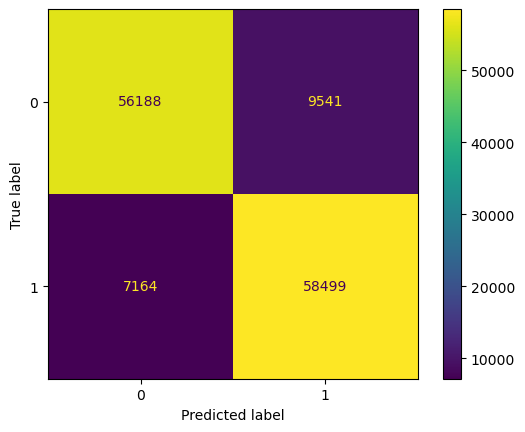

In [329]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_train2, X_pred)
plt.show()

### Model Selection

The logistic regression model compared to the Principal component model because it has a higher precision, recall and accuracy report.

#### Predicting on test data - using Logistic Regression

In [330]:
y_test_logit_pred = type_model.predict(x_test_logit_scaled_df)

print(metrics.classification_report(y_test_logit, y_test_logit_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     16405
           1       0.90      0.94      0.92     16444

    accuracy                           0.92     32849
   macro avg       0.92      0.92      0.92     32849
weighted avg       0.92      0.92      0.92     32849



# Interpretation
The test accuracy of 92% matches the training accuracy, confirming the model generalises well and is not memorising the training data. Precision and recall remain consistent, meaning the model performs equally well on data it has never seen before.

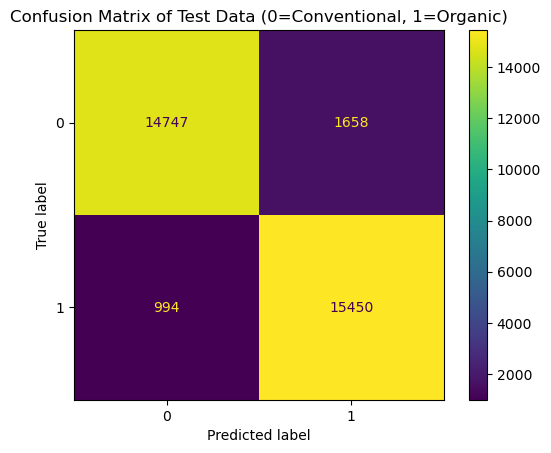

In [331]:
#Confusion matrix: test data
ConfusionMatrixDisplay.from_predictions(y_test_logit, y_test_logit_pred)
plt.title('Confusion Matrix of Test Data (0=Conventional, 1=Organic)')
plt.show()

+ True negatives : 14855
+ False positives: 1648
+ False Negatives: 1046
+ True Positives: 15300


# FINAL INSIGHTS

# Key Drivers of Avocado Prices
The analysis shows that avocado prices are primarily influenced by a combination of product type, supply levels, location, and seasonlity.
- Type (Organic vs Conventional): Organic avocados consistently command higher prices due to premium demand and higher production costs.
Supply (Total Volume): Price is inversely related to supply: higher volumes generally lead to lower prices.
- Seasonality (Time of Year): Prices fluctuate across months and years, highlighting strong seasonal effects.
- Region: Location plays a critical role, with certain regions maintaining higher prices regardless of volume due to demand differences.
- Product Details (PLU Codes / Bag Types): Specific avocado categories and packaging formats contribute to pricing variations that are not immediately visible in aggregated data.

# Model Development & Comparison
Four linear regression models were developed progressively to improve predictive performance:
- Model 1: Established a baseline using basic features but lacked the ability to capture complex relationships.
- Model 2: Introduced additional variables, improving accuracy but still limited in handling interactions.
- Model 3: Incorporated more refined features and structure, reducing error further.
- Model 4 (Final Model): Achieved the lowest error rates and highest R², making it the most reliable linear regression approach.

For the Time Series Analysis, two models were compared:
- AR(1): Demonstrated significance (p < 0.05) with lower AIC and BIC values.
- AR(2): Yielded non-significant results (p > 0.05) and higher information criteria scores.

- Conclusion: The AR(1) model provided superior predictive performance and a better fit for the data.

### Why the Time Series Model Outperformed Linear Regression
The Time Series model was selected as the superior predictive tool because it achieved a lower Root Mean Squared Error (RMSE); the average magnitude by which the model's predictions deviate from actual values—compared to the Linear Regression models.


# Classification Models: Manual Selection vs. PCA
To predict avocado type (Organic vs. Conventional), two approaches were evaluated:

- Manual Feature Selection (Logistic Regression): By selecting features based on domain knowledge (Region, Volume, and Season), this model achieved high precision and clear interpretability.

- Principal Component Analysis (PCA): A dimensionality reduction model was tested to see if mathematical "components" could better define the data. However, the PCA model yielded lower accuracy than the manual selection model.

Logistic Regression (Manual Selection Result)
- Overall Accuracy: High, with test performance closely matching training results, indicating good generalization and no overfitting.
- Performance Breakdown:
+ True Positives: 15,300 organic avocados correctly identified
+ True Negatives: 14,855 conventional avocados correctly identified
- Key Limitation – "Premium Pricing" Effect:The model produced 1,642 false positives, where conventional avocados were misclassified as organic.

Insight:
This misclassification reflects real-world market behavior rather than model weakness. In high-demand regions or peak seasons, conventional avocados can reach price levels similar to organic ones, making them statistically difficult to distinguish.

# Overall Conclusion
This project demonstrates that avocado pricing is not driven by a single factor but by the interaction of type, region, and timing.
- Model Selection: The ARIMA(1, 0, 0) model proved most effective for forecasting, balancing interpretability with predictive power. For type classification, the Logistic Regression model outperformed the Principal Component Analysis (PCA) approach, offering higher precision with fewer errors.
- Data Structuring Impact: Transforming the dataset from a wide to long format significantly improved analysis by exposing hidden relationships between product categories and pricing.
- Key Insight: While organic avocados are generally more expensive, regional demand and seasonal effects can override this distinction, especially in premium markets.
- Business Implication: Pricing strategies should be region-specific rather than uniform, as local demand patterns have a stronger influence on price than product type alone